Two Qubit Control in Rydberg Blockade
=========================

TODO
- code the double bloch sphere 
- make visuals
- tune matt chow gate to the required phase accumulation for the CZ equivalent gate

We know that our $SU(2)$ ops on each qubit and a large enough interaction $V_{rr}$, we can think of the system as two block spheres. The action on the $\left| 00 \right>$ state can be ignored, and the $\left| 01 \right>$ and $\left| 10 \right>$ have the same evolution. This means the two states we can look at are $\left| 01 \right>$ and $\left| 11 \right>$ states:
$$
\hat{H}_{01} \rightarrow
\left[
    \begin{matrix}
        0 & \Omega/2 \\
        \Omega/2 & -\Delta
    \end{matrix} 
\right] \
\,
\text{and}
\,\,\,
\hat{H}_{11} \rightarrow
\left[
    \begin{matrix}
        0 & \Omega/\sqrt{2} \\
        \Omega/\sqrt{2} & -\Delta
    \end{matrix} 
\right]
$$

This means we still only get to really control the same three parameters ($\Omega$, $\Delta$, $\phi$), but now have three results we want to fix in place ($_{01}\bra{0}\ket{\psi{(T)}} = 1$, $_{11}\bra{0}\ket{\psi{(T)}} = 1$, $\xi_{11}-2\xi_{01}=\pi$).

In [1]:
# setting up stuff
using QuantumOptics
using LinearAlgebra

computational = SpinBasis(1//2)

I = identityoperator(computational)
σx = sigmax(computational)
σy = sigmay(computational)
σz = sigmaz(computational)
σ_vec = [σx, σy, σz];

down = spindown(computational)
up = spinup(computational)
;

Want to be able to represent a spin $\tfrac{1}{2}$ system so we can test the time evolution of different pulses. Our Hamiltonian can be controlled by a laser. A laser can be controlled by the intensity, frequency, and phase. While not exactly the same, these can be mapped to three parameters in our Hamiltonian:
$$
\text{intensity} \mapsto \Omega(t) \\
\text{frequency} \mapsto \Delta(t) \\
\text{phase} \mapsto \phi(t) 
$$
which appear in the Hamiltonian as follows:
$$
\hat{H}(\Delta(t), \Omega(t), \phi(t)) = \frac{-\Delta(t)}{2}\hat{1} 
    - \frac{-\Delta(t)}{2}\hat{\sigma}_z 
    + \frac{\Omega(t)}{2}
        (
            \cos{\phi(t)}\hat{\sigma}_x +
            \sin{\phi(t)}\hat{\sigma}_y
        )
    = -\frac{1}{2}\Delta(t)\hat{1} + \frac{1}{2}\tilde{\vec{\Omega}}(t) \cdot \hat{\vec{\sigma}}
$$

In [2]:
function twoLevelSysFromParameters(Ψ₀::StateVector, Δ::Function, Ω::Function, ϕ::Function, T::Real; number_of_reported_times::Int = 100)
    H(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, number_of_reported_times)
    tout, psi_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H)
    return tout, psi_t, t->H(t, nothing)
end

function rydberg_blockaded_system(Ψ₀::StateVector, Δ::Function, Ω::Function, ϕ::Function, T::Real; number_of_reported_times::Int = 100)
    H_01(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 
    H_11(t, ignored) = sqrt(2)*Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, number_of_reported_times)
    tout, psi01_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_01)
    _,    psi11_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_11)
    return tout, (psi01_t, t->H_01(t, nothing)), (psi11_t, t->H_11(t, nothing))
end

rydberg_blockaded_system (generic function with 1 method)

In [3]:
include("./Plotting.jl")
include("./Utils.jl")
using CairoMakie
using IJulia

Δ(t) = -1
Ω(t) = 1
ϕ(t) = 0
T=2π/sqrt(3)

filename01 = "./graphics/simple_double_bloch01.gif"
filename11 = "./graphics/simple_double_bloch11.gif"
tout, (psi01_t, H_01), (psi11_t, H_11) = rydberg_blockaded_system(down, Δ, Ω, ϕ, T)
save_bloch_animation(tout, psi01_t, 5, 24, filename01, title="|01>")
save_bloch_animation(tout, psi11_t, 5, 24, filename11, title="|11>")

display("text/html", """
<img src="$filename01" width=400>
<img src="$filename11" width=400>
""")


Fidelity measure
-----------------
We can repeat the gate that was done by the Sandians (Matt, Bethany, Saurabh, etc) which was inspired by the adiabatic gate but was faster. I will call this the "Inspired by Adiabtic" (IBA) gate in this notebook. 

I would like to define Fidelity of my implemented gate $\hat{U}$ as 
$$
4\mathscr{F} = Tr(\hat{C}_z \hat{U}) 
= \sum_i^{\{0, 1, r\}}\sum_j^{\{0, 1, r\}} \bra{ij} \hat{C}_z \hat{U} \ket{ij} 
$$

Now I assume we start in a computational state $\{\ket{00}, \ket{01}, \ket{10}, \ket{11}\}$ and we don't want to count any population that ended outside of our computational basis towards our fidelity.
$$
= \sum_i^{\{0, 1\}}\sum_j^{\{0, 1\}} \bra{ij} \hat{C}_z \hat{U} \ket{ij} 
$$

we also assume nothing happens to $\ket{00}$ and the exact same action happens to $\ket{01}$ and $\ket{10}$:
$$
= \bra{00} \hat{C}_z \hat{U} \ket{00} + \bra{01} \hat{C}_z \hat{U} \ket{01} + \bra{10} \hat{C}_z \hat{U} \ket{10} + \bra{11} \hat{C}_z \hat{U} \ket{11} \\
= 1 + 2\bra{01} \hat{C}_z \hat{U} \ket{01} + \bra{11} \hat{C}_z \hat{U} \ket{11} \\
$$

Now there is a trickyness here. $\hat{C}_z$ in our equation isn't exactly the control-$Z$ that we know and love, just up to local $SU(2)$ ops on single qubits. This means the phases needed must satisfy $$2\phi_{01} - \phi_{11} = \pi \mod 2\pi$$ 
To use this we would have to define a specific $\phi_{10}$ we want to implement and see how good our fidelity is compared to that. For now I am going to claim that any gate that implements a control-$Z$ is goo enough by claiming that I can know what the value of $\phi_{01}$ is no matter what.
$$
= 1 + 2 \left|\bra{01} \hat{C}_z \hat{U} \ket{01} \right| + e^{\pi-2\phi_{01}}\bra{11} \hat{C}_z \hat{U} \ket{11} \\
= 1 + 2 \left|\bra{01} \hat{C}_z \hat{U} \ket{01} \right| + e^{\pi-2\phi_{01} + \phi_{11}} \left| \bra{11} \hat{C}_z \hat{U} \ket{11} \right| \\
$$ 

To explain, we always get full $00$ return, and if we have fill population return of both $01$ and $11$ in addition to 
$$
\pi-2\phi_{01} + \phi_{11} = 0 \mod 2\pi
$$
then we get a value of $4 \mathscr{F}=4$!

In the code here we implement a $\sqrt{C_Z}$ gate instead, that way we can perform a spin-echo and cancel out inhomogeneous noise.

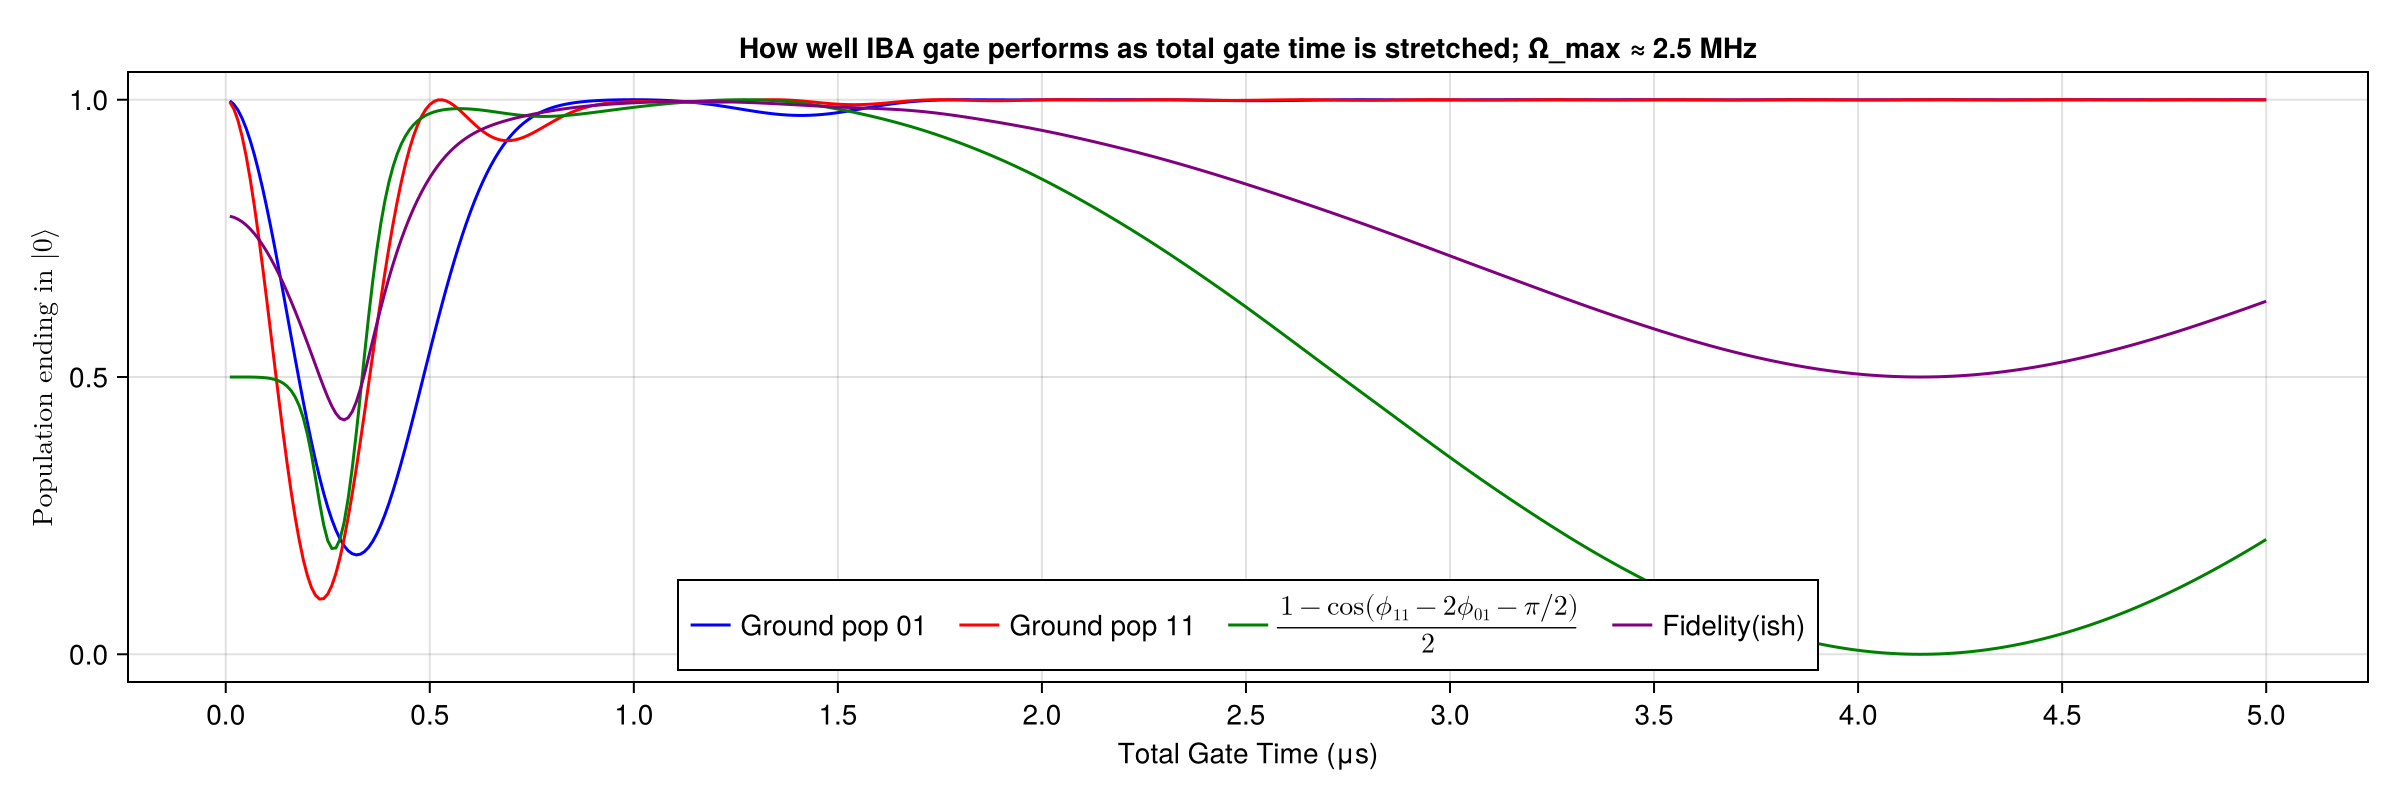

CairoMakie.Screen{IMAGE}


In [ ]:
using Interpolations
using QuantumOptics
using CairoMakie

"""
runs the inspired by adiabaticity gate (IBA) on the 4 level rydberg blockade system
"""
function iba_gate(T::Real, Ω_max=2.45025)
    Ω_points = 2π*[0.0, 0.277, 0.556, 0.833, 1.0, 1.0, 0.833, 0.556, 0.277, 0.0]

    Δ_points = 2π .* [4.08, 3.06, 2.04, 1.02, 0.408, 0.408, 1.02, 2.04, 3.06, 4.08] #MHz I think

    ts = range(0, T, length(Ω_points))
    Δ(t) = cubic_spline_interpolation(ts, Δ_points)(t) # this could also be `Ω = cubic_spline_interpolation(ts, Ω_points)` ¯\_(ツ)_/¯
    helper(t) = cubic_spline_interpolation(ts, Ω_points)(t)
    Ω(t) = Ω_max * helper(t)/helper(T/2)*2π
    ϕ(t) = 0

    (tout, psi_t, H) = twoLevelSysFromParameters(down, Δ, Ω, ϕ, T)
    return (tout, psi_t, H), (Δ, Ω, ϕ) # returns a lot of stuff but they are all useful
end


iterations = 500
tmin = 0.01
tmax = 5
Ts = range(tmin, tmax, iterations)

# 01 bloch sphere
gate_01_results = iba_gate.(Ts, 2.5)
psi_t = getindex.(getindex.(gate_01_results,1), 2)
psi_end = getindex.(psi_t, length(psi_t[1]))
down_end_amplitude = getindex.(psi_end, 2)
ending_population_01 = abs2.(down_end_amplitude)
zero_inner_01 = abs.(down_end_amplitude)
ϕ_01 = angle.(down_end_amplitude)

# 11 bloch sphere
gate_11_results = iba_gate.(Ts, sqrt(2)*2.5)
psi_t = getindex.(getindex.(gate_11_results,1), 2)
psi_end = getindex.(psi_t, length(psi_t[1]))
down_end_amplitude = getindex.(psi_end, 2)
ending_population_11 = abs2.(down_end_amplitude)
zero_inner_11 = abs.(down_end_amplitude)
ϕ_11 = angle.(down_end_amplitude)

phase_accum = ϕ_11 .- 2 .* ϕ_01
cos_phase_accum = (1 .+ cos.(phase_accum .- π/2)) ./ 2
fidelity = abs.((1 .+ 2 .* zero_inner_01 .+ cis.(phase_accum .- π/2 ) .* zero_inner_11) ./ 4)


# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well IBA gate performs as total gate time is stretched; Ω_max ≈ 2.5 MHz",
    xlabel = "Total Gate Time (μs)",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (0:0.5:tmax)
)

lines!(ax1, Ts, ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, Ts, ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, Ts, cos_phase_accum, color = :green, label = L"\frac{1-\cos(\phi_{11} - 2\phi_{01} - \pi/2)}{2}")
lines!(ax1, Ts, fidelity, color = :purple, label = "Fidelity(ish)")

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)

In [4]:
maxF, index = findmax(fidelity)
maxF_time = Ts[index]

print("F(t=$maxF_time)=$maxF")

F(t=1.14)=0.9969400259297319

This looks great. We have implemented a $\sqrt{C_Z}$ gate! Lets look at a few other intensities.

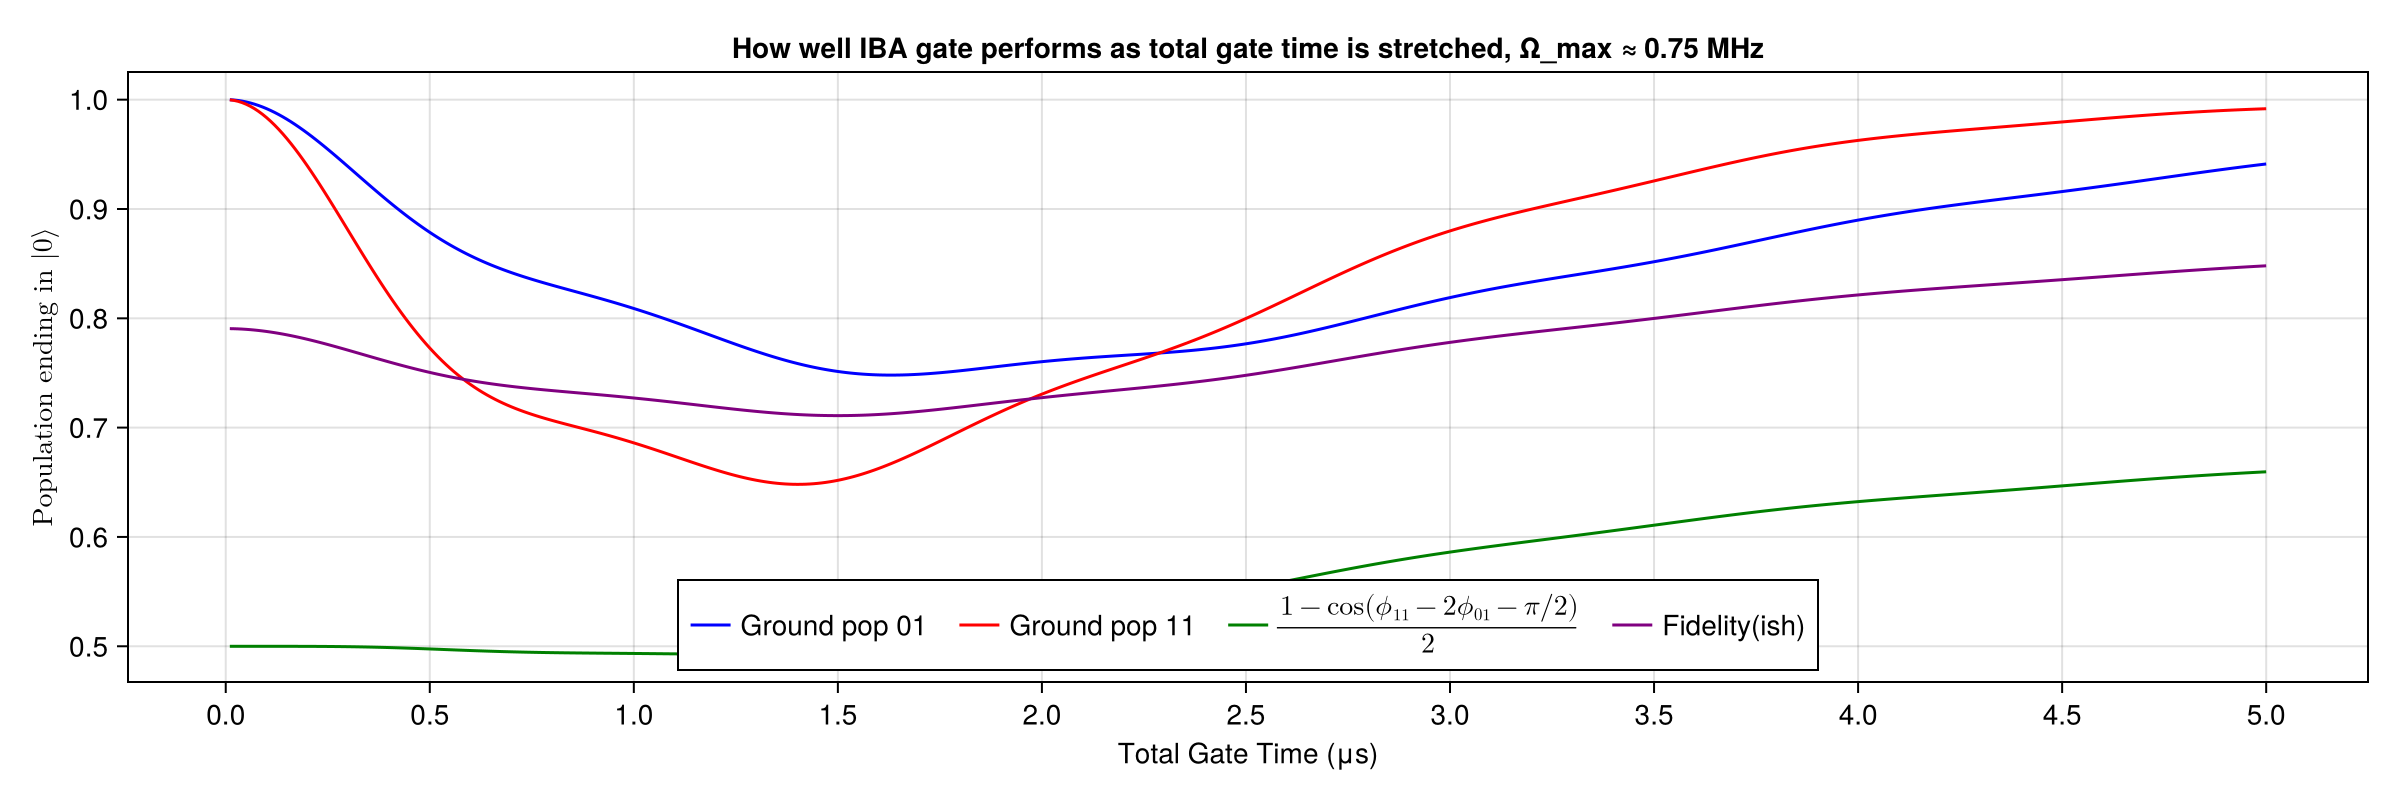

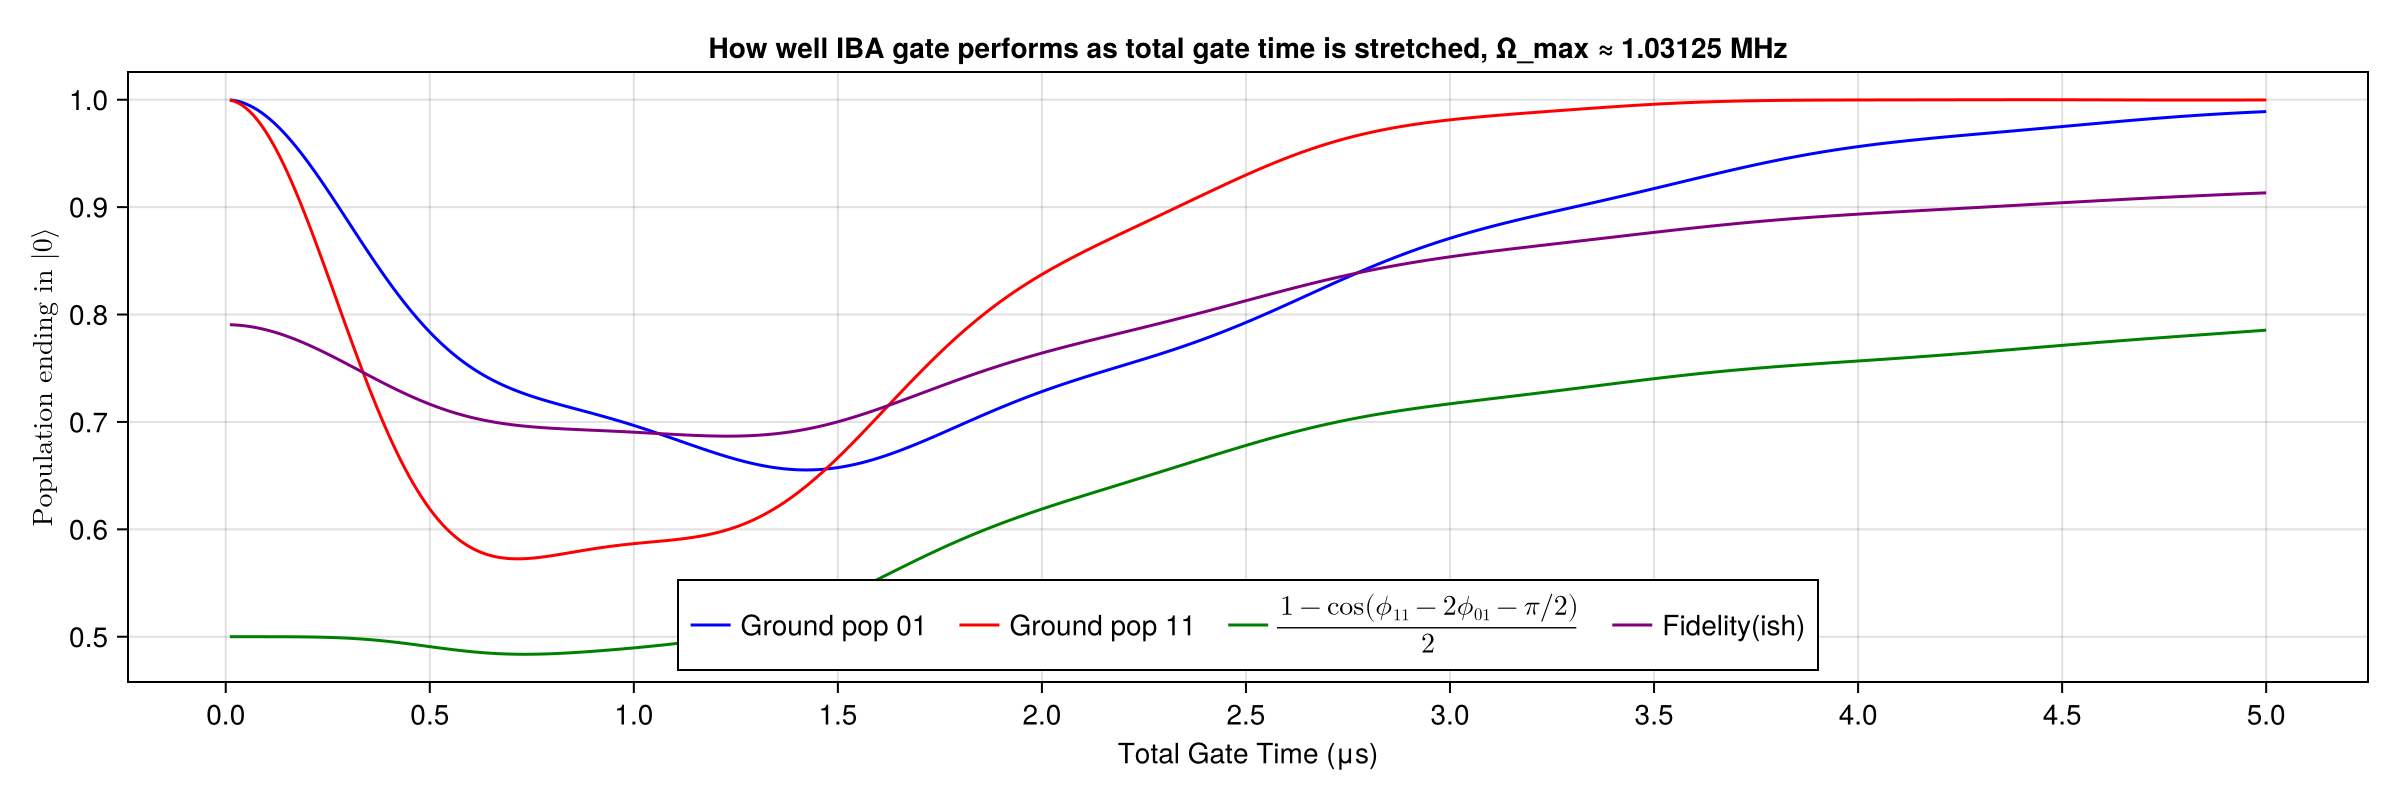

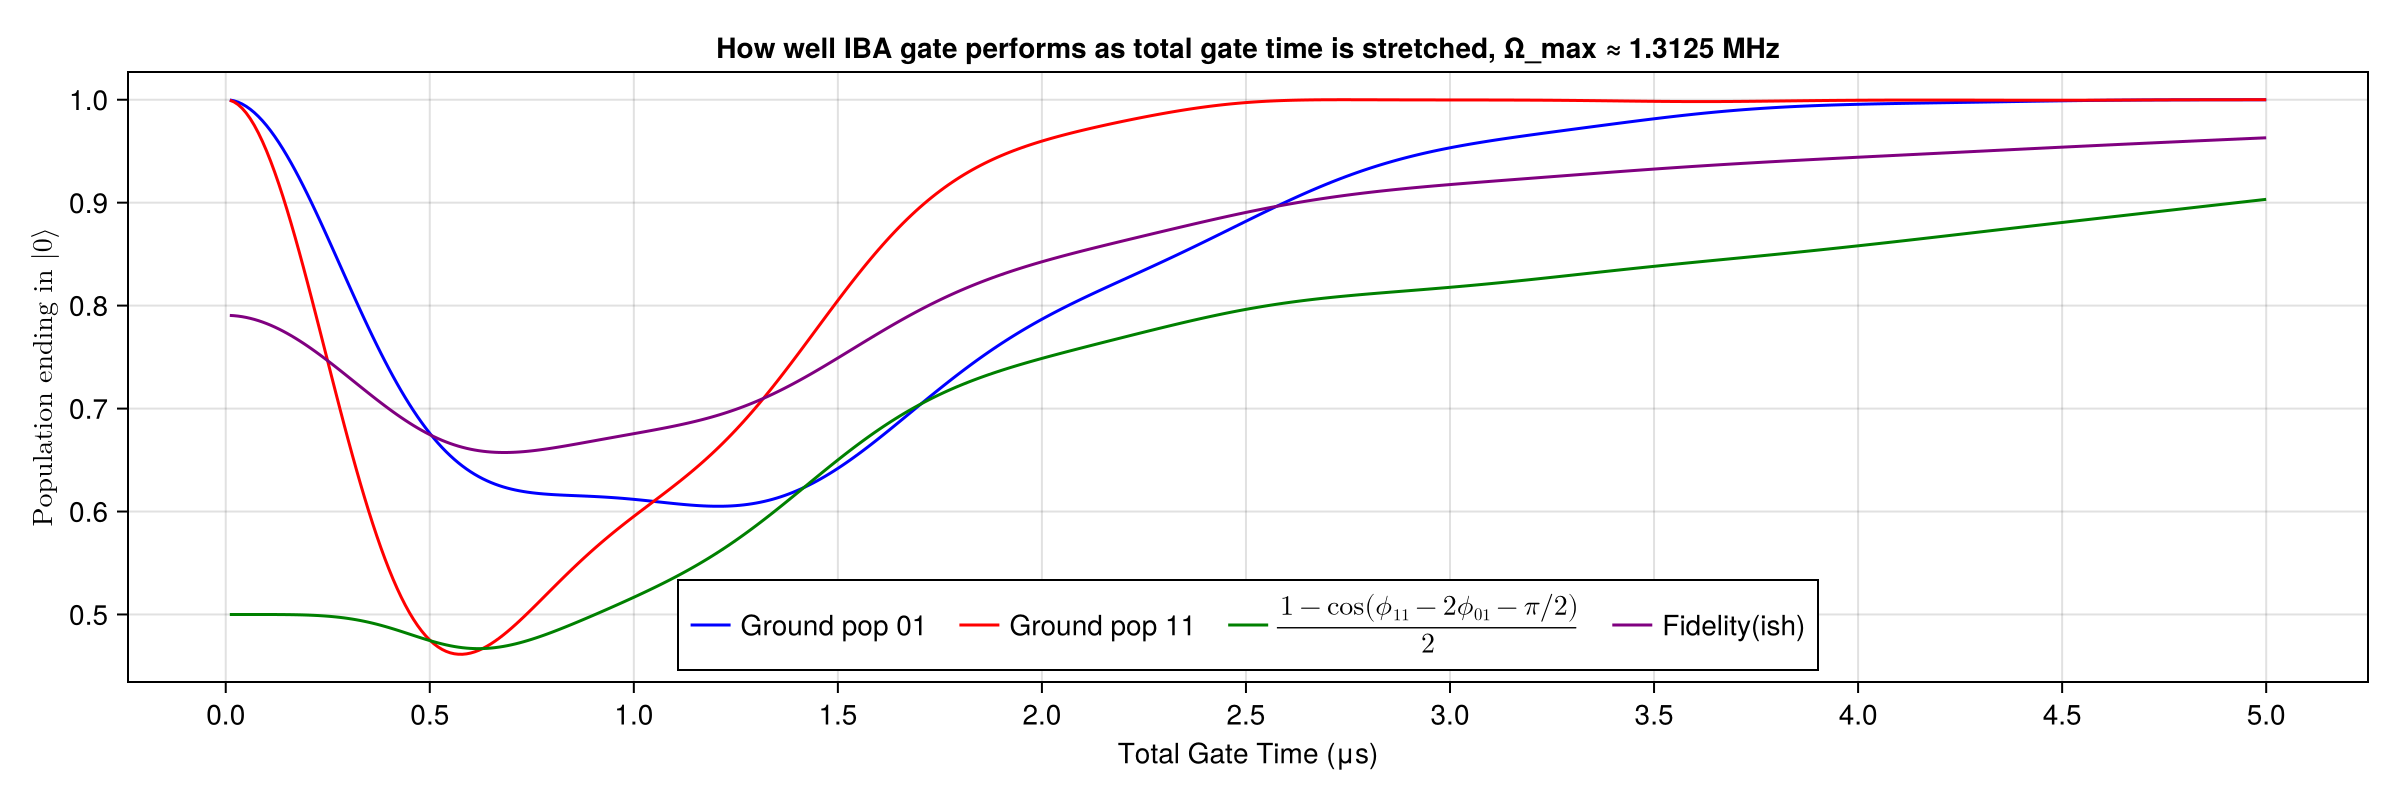

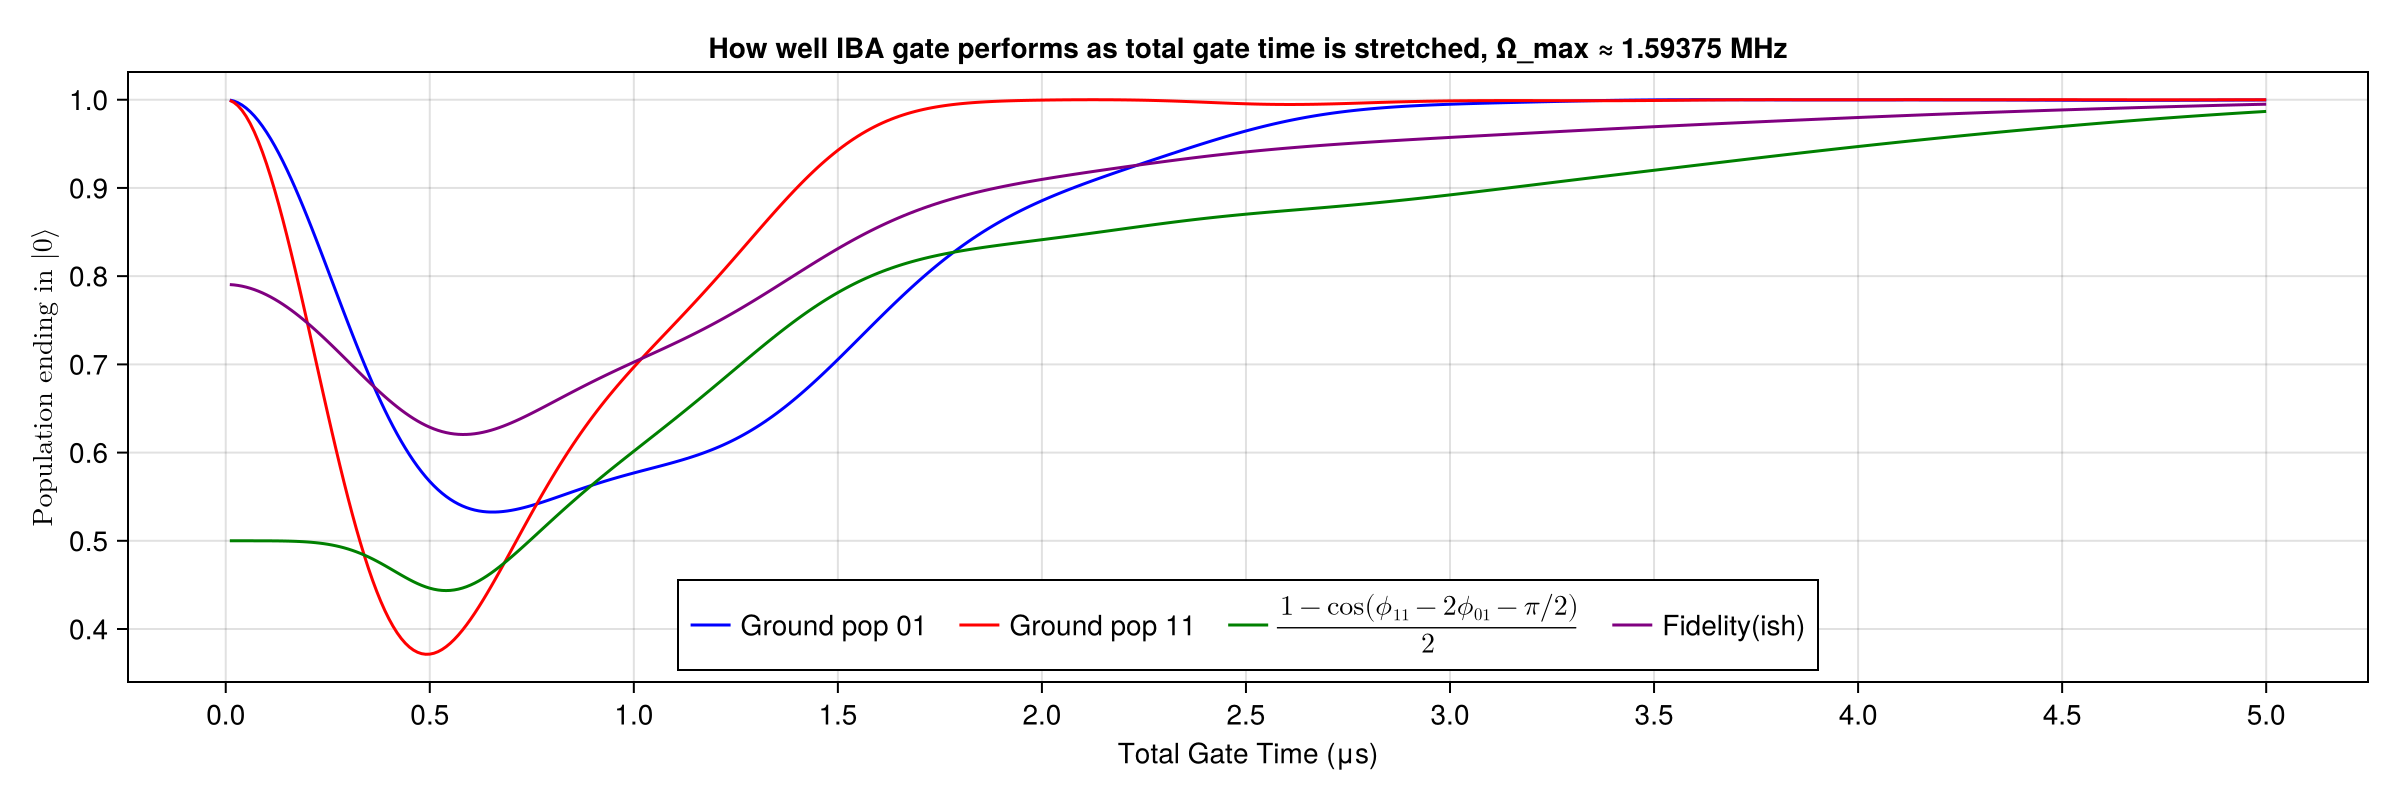

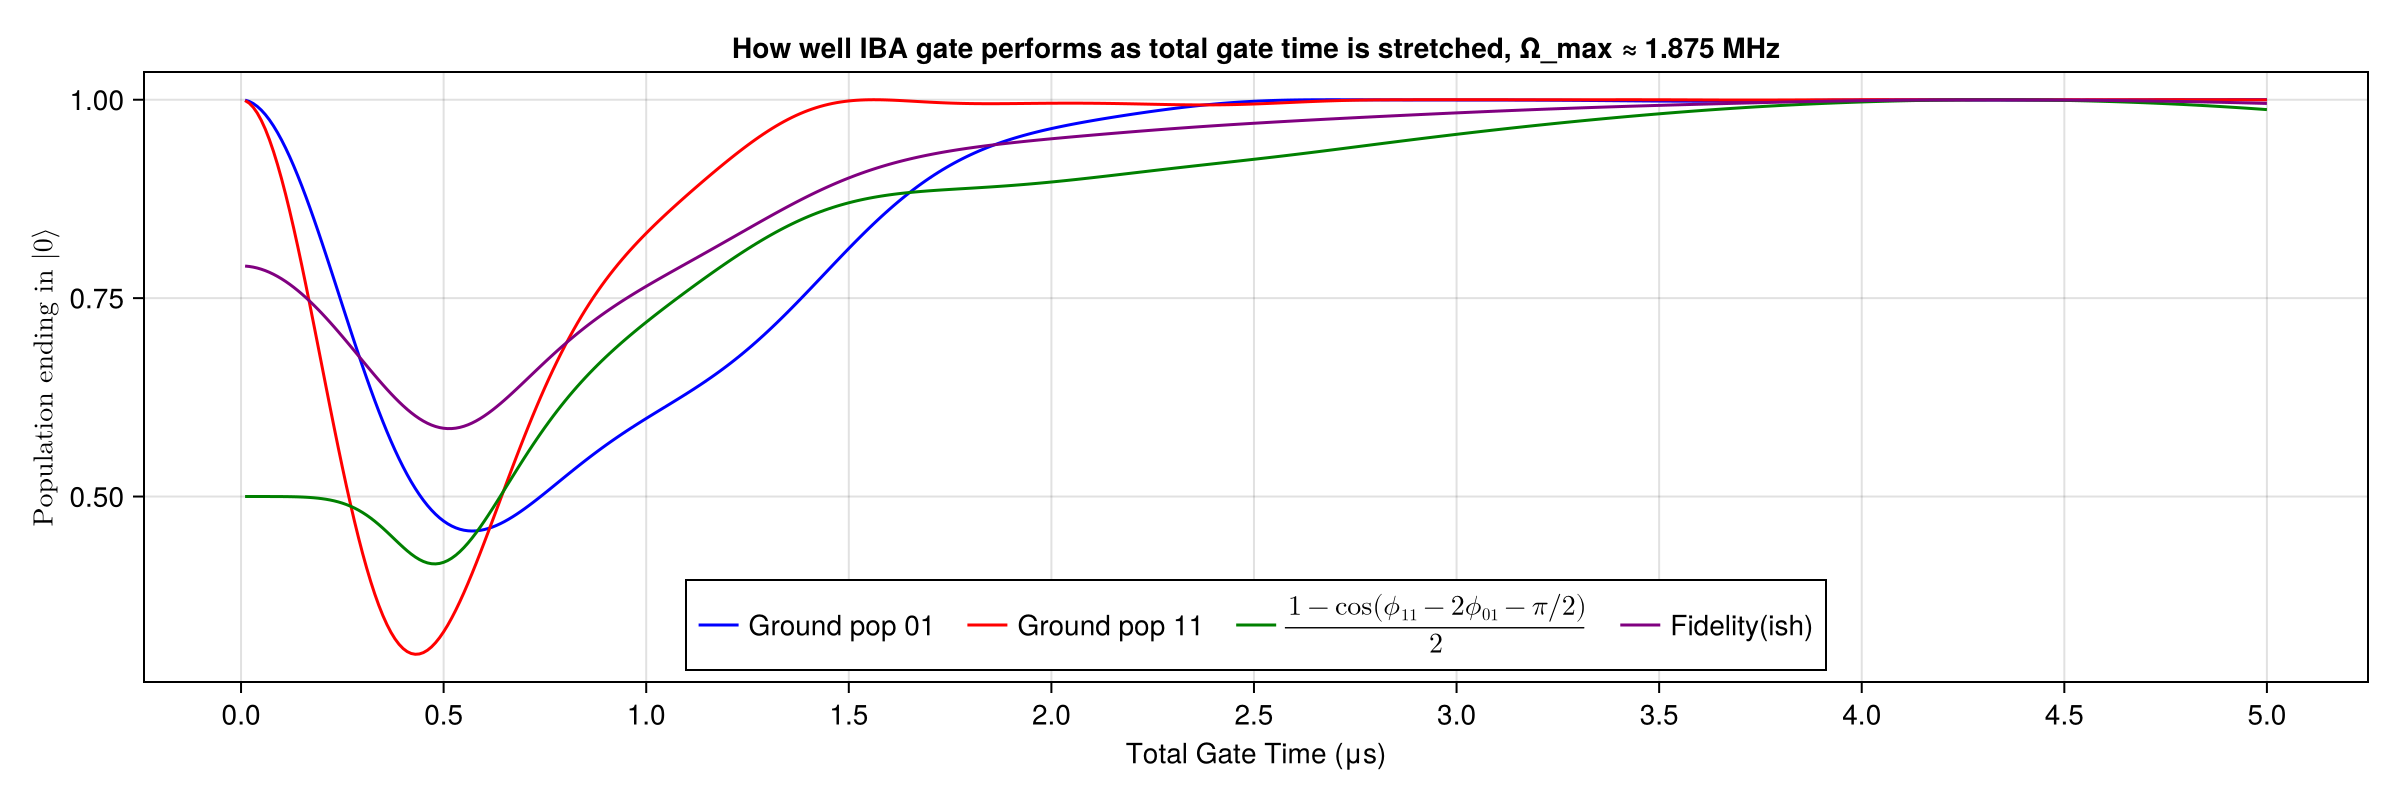

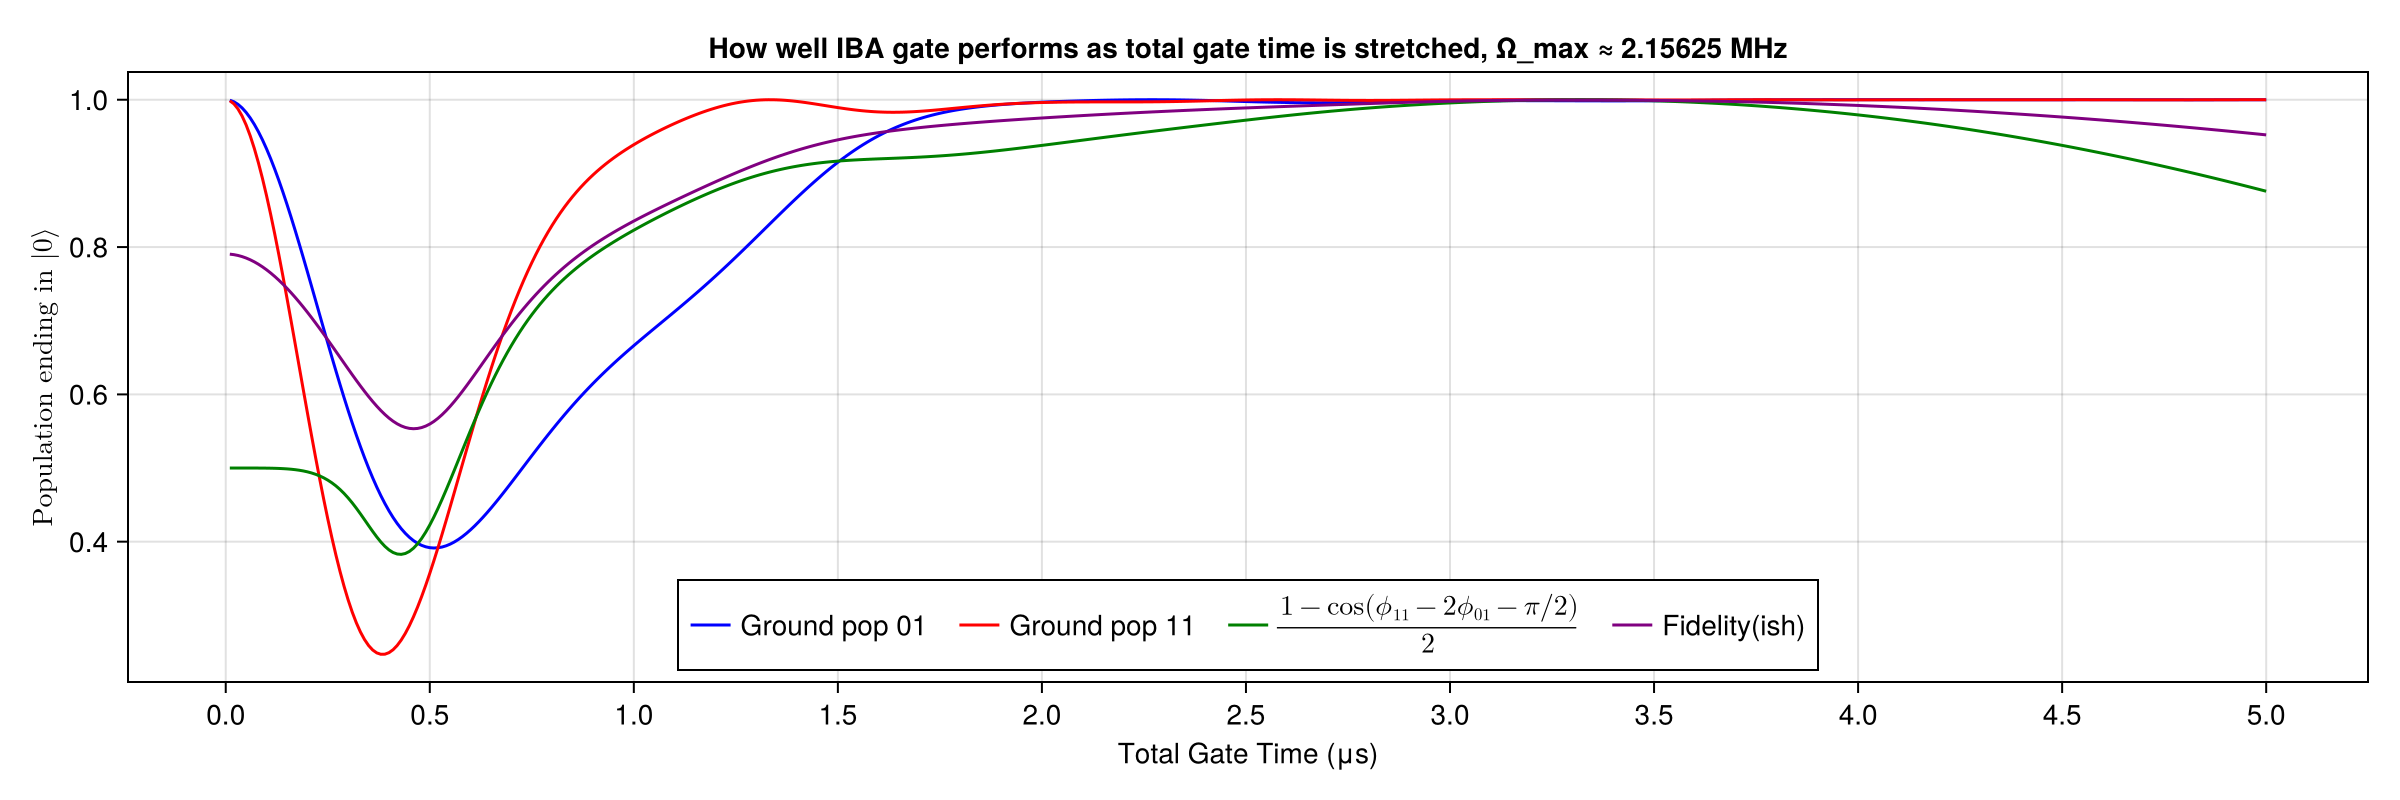

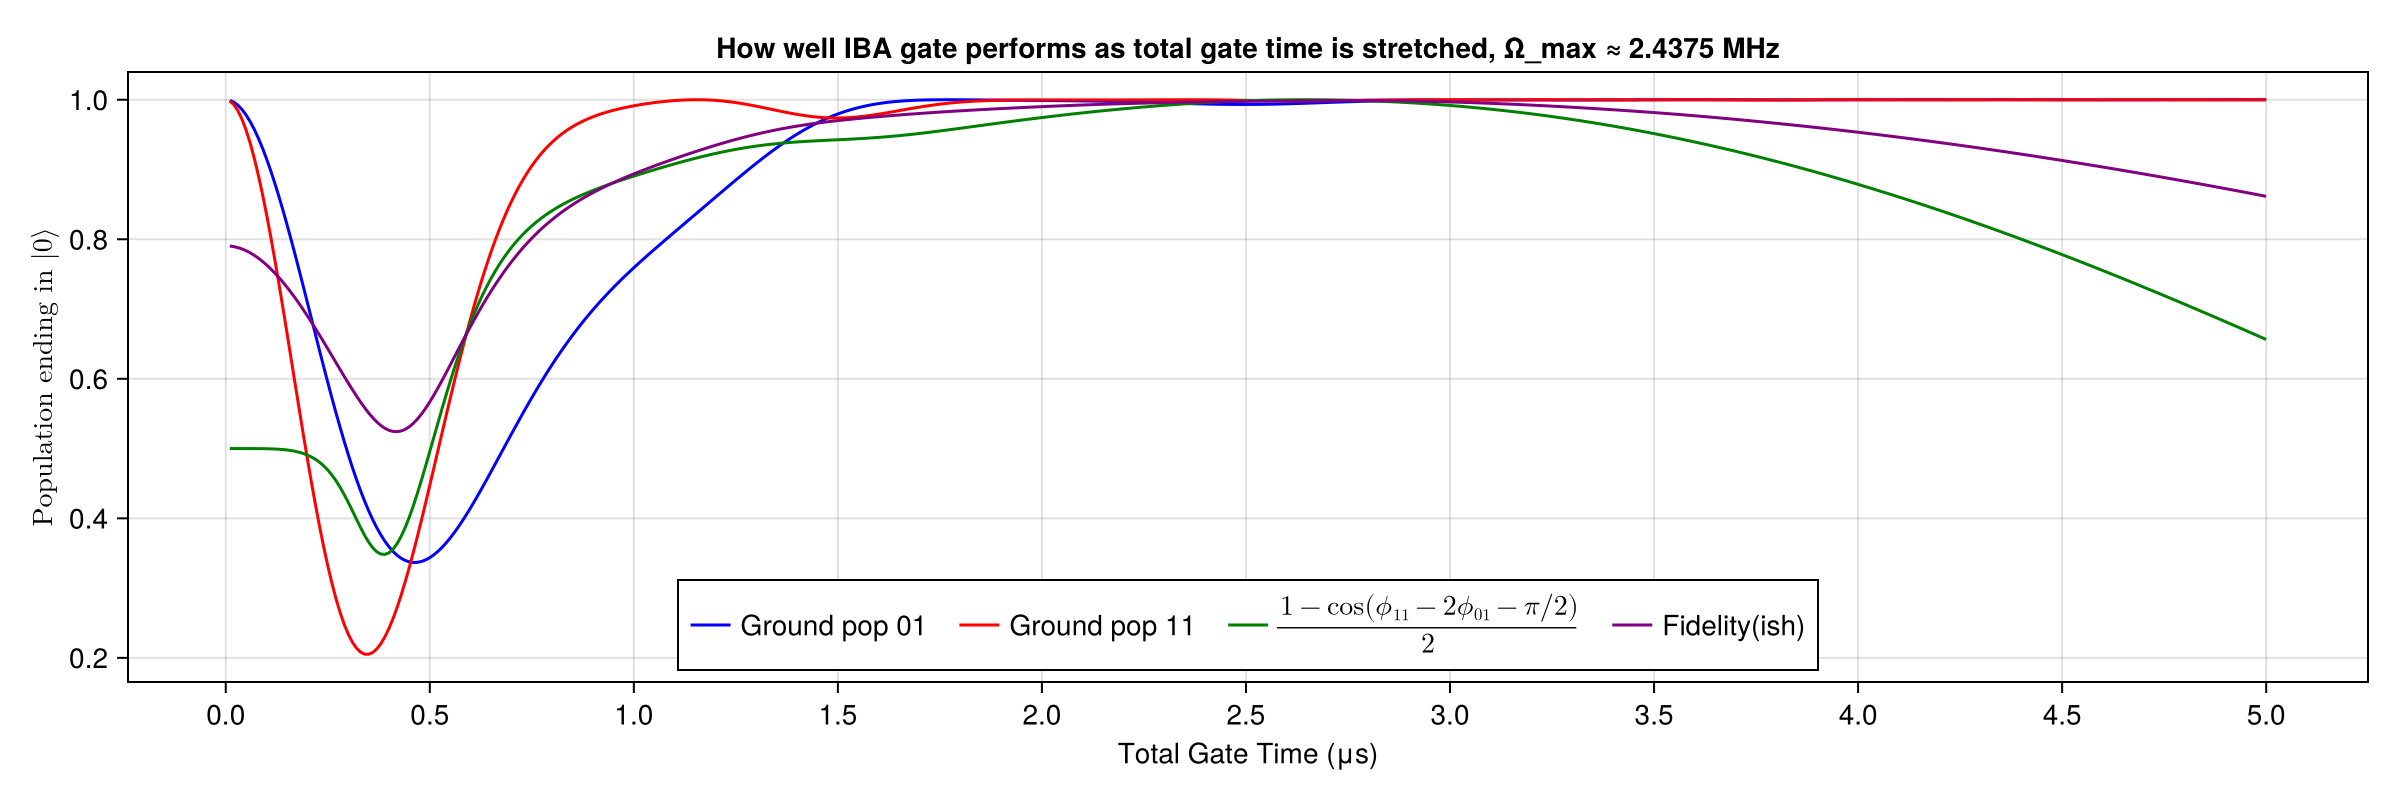

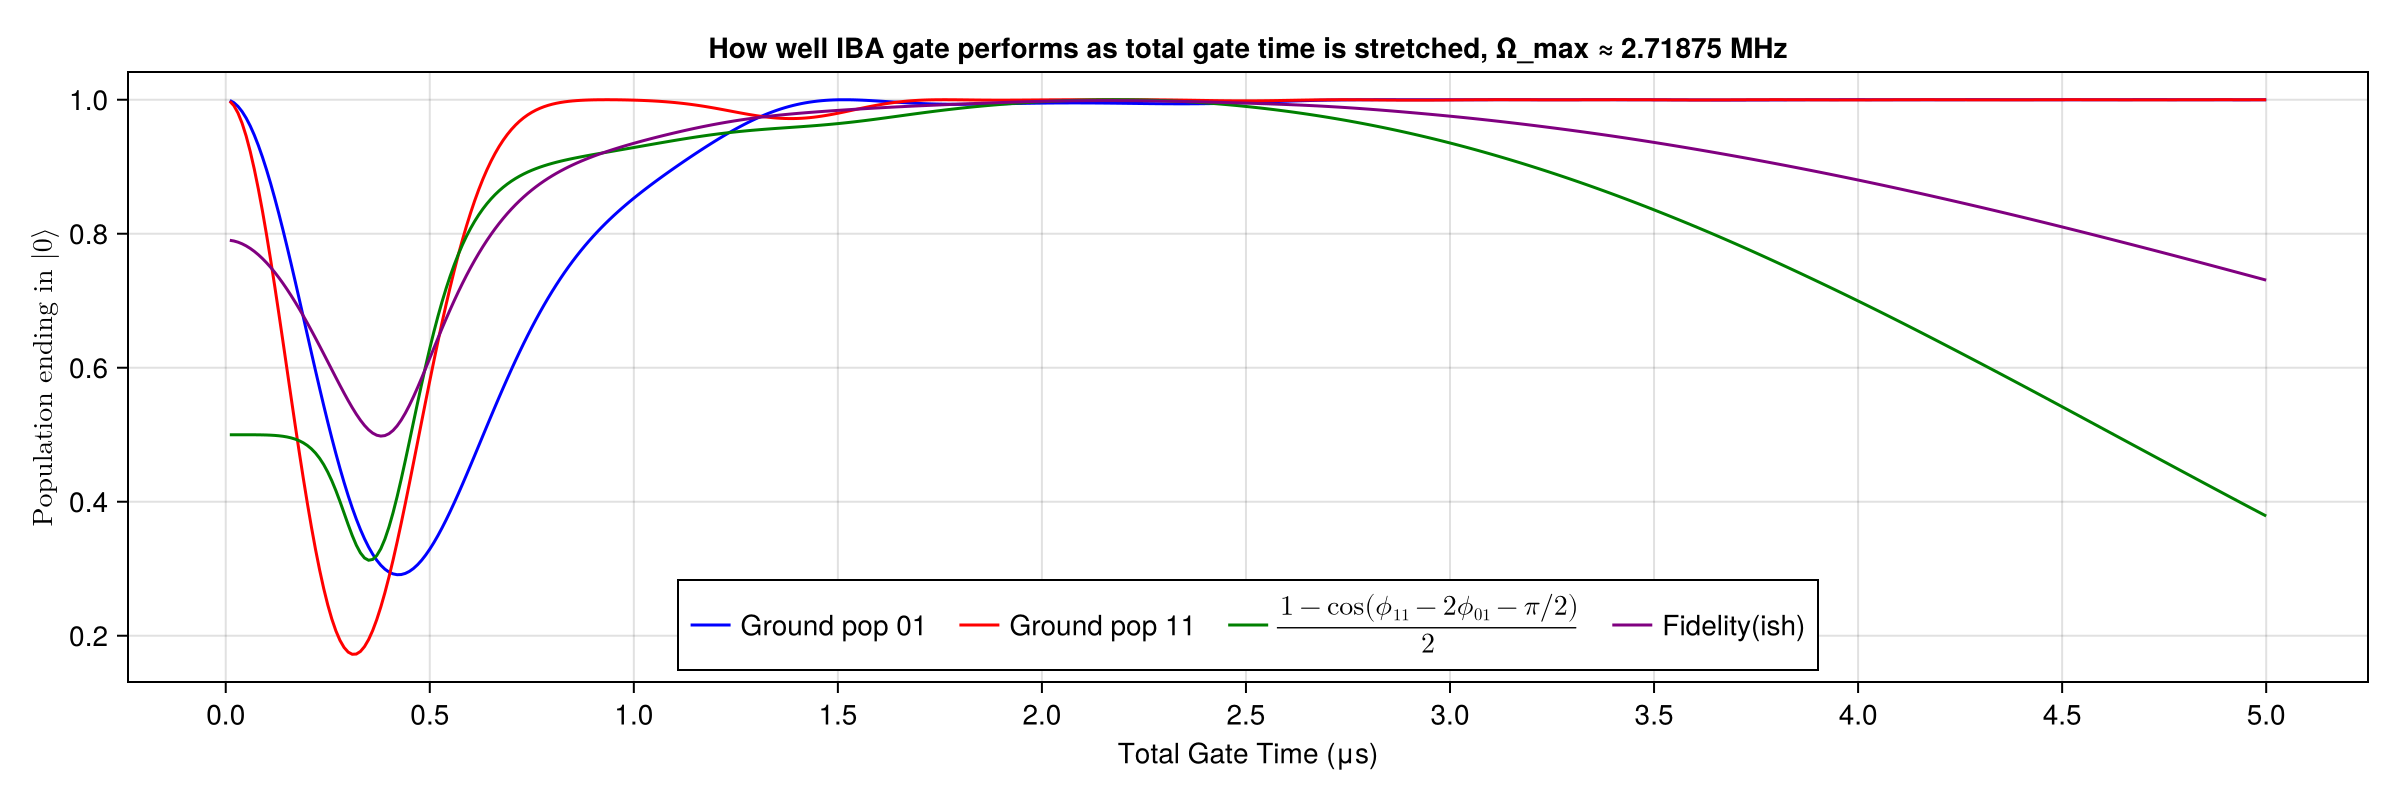

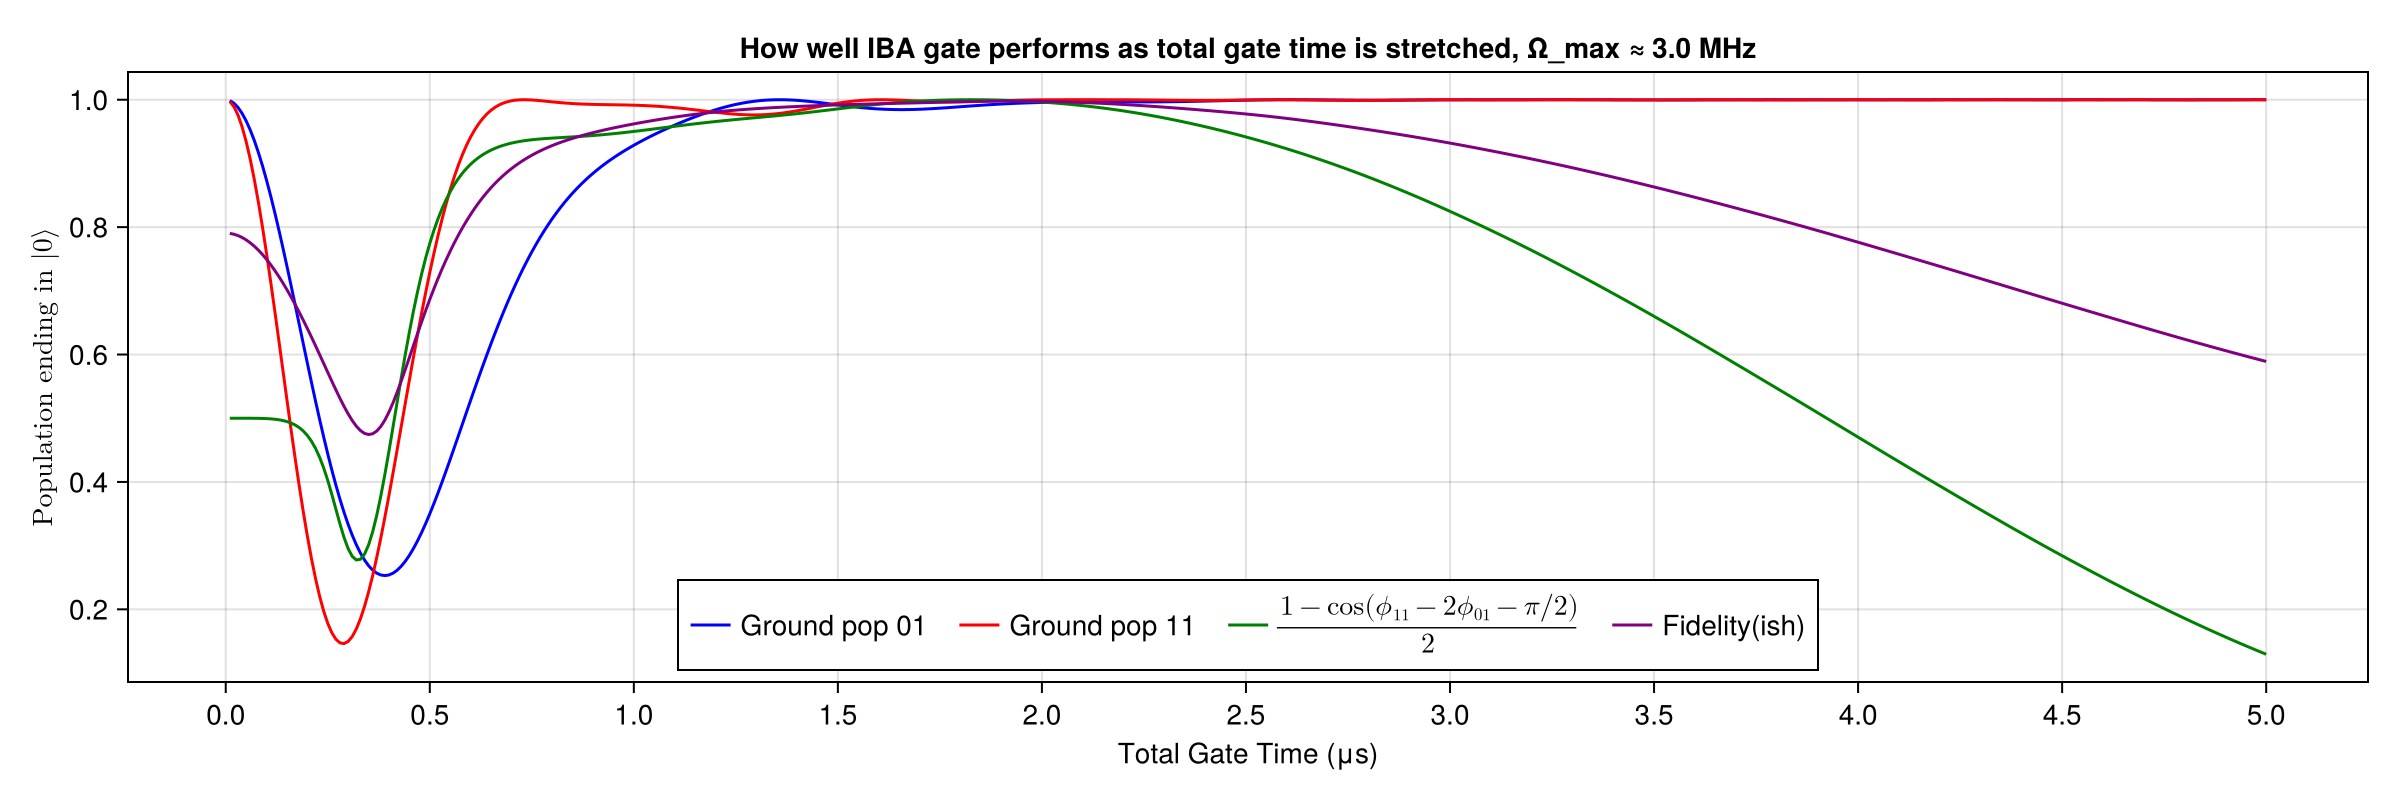

In [6]:
using Interpolations
using QuantumOptics
using CairoMakie

for Ω_multiplier in range(0.5, 2.0,9)

    iterations = 500
    tmin = 0.01
    tmax = 5
    Ts = range(tmin, tmax, iterations)

    new_iba_gate(T, newmult) = iba_gate(T, Ω_multiplier*newmult)
    # 01 bloch sphere
    gate_01_results = new_iba_gate.(Ts, 1)
    psi_t = getindex.(getindex.(gate_01_results,1), 2)
    psi_end = getindex.(psi_t, length(psi_t[1]))
    down_end_amplitude = getindex.(psi_end, 2)
    ending_population_01 = abs2.(down_end_amplitude)
    zero_inner_01 = abs.(down_end_amplitude)
    ϕ_01 = angle.(down_end_amplitude)

    # 11 bloch sphere
    gate_11_results = new_iba_gate.(Ts, sqrt(2))
    psi_t = getindex.(getindex.(gate_11_results,1), 2)
    psi_end = getindex.(psi_t, length(psi_t[1]))
    down_end_amplitude = getindex.(psi_end, 2)
    ending_population_11 = abs2.(down_end_amplitude)
    zero_inner_11 = abs.(down_end_amplitude)
    ϕ_11 = angle.(down_end_amplitude)

    phase_accum = ϕ_11 .- 2 .* ϕ_01
    cos_phase_accum = (1 .+ cos.(phase_accum .- π/2)) ./ 2
    fidelity = abs.((1 .+ 2 .* zero_inner_01 .+ cis.(phase_accum .- π/2 ) .* zero_inner_11) ./ 4)


    # plotting
    fig = Figure(size=(1200, 400))
    ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
        title = "How well IBA gate performs as total gate time is stretched, Ω_max ≈ $(Ω_multiplier*1.5) MHz",
        xlabel = "Total Gate Time (μs)",
        ylabel = L"Population ending in $|0\rangle$",
        xticks = (0:0.5:tmax)
    )

    lines!(ax1, Ts, ending_population_01, color = :blue, label = "Ground pop 01")
    lines!(ax1, Ts, ending_population_11, color = :red, label = "Ground pop 11")
    lines!(ax1, Ts, cos_phase_accum, color = :green, label = L"\frac{1-\cos(\phi_{11} - 2\phi_{01} - \pi/2)}{2}")
    lines!(ax1, Ts, fidelity, color = :purple, label = "Fidelity(ish)")

    axislegend(ax1, position = :cb, orientation = :horizontal)

    display(fig)
end

Can we do simple gradient-free optimization on just the length of the gate $T$ and the maximum rabi frequency $\Omega_{max}$.

In [15]:
using Interpolations
using QuantumOptics
using CairoMakie


Ω_points = 2π .* [0.0, 0.412, 0.825, 1.237, 1.485, 1.485, 1.237, 0.825, 0.412, 0.0] #MHz I think
Δ_points = 2π .* [4.08, 3.06, 2.04, 1.02, 0.408, 0.408, 1.02, 2.04, 3.06, 4.08] #MHz I think
ts = range(0, 1, length(Ω_points))

Δ_0(t) = cubic_spline_interpolation(ts, Δ_points)(t) # this could also be `Ω = cubic_spline_interpolation(ts, Ω_points)` ¯\_(ツ)_/¯
Ω_helper(t) = cubic_spline_interpolation(ts, Ω_points)(t) 
Ω_0(t) = Ω_helper(t)/Ω_helper(1/2)*2π

function iba_infidelity(T::Real, Ω_max=1)
    Δ(t) = Δ_0(t/T)
    Ω_01(t) = Ω_max*Ω_0(t/T)
    Ω_11(t) = sqrt(2)*Ω_max*Ω_0(t/T)
    ϕ(t) = 0

    (_, psi_01_t, H) = twoLevelSysFromParameters(down, Δ, Ω_01, ϕ, T)
    (_, psi_11_t, H) = twoLevelSysFromParameters(down, Δ, Ω_11, ϕ, T)

    # 01 bloch sphere
    psi_01_end = psi_01_t[end]
    down_end_amplitude = getindex(psi_01_end, 2)
    ending_population_01 = abs2(down_end_amplitude)
    zero_inner_01 = abs(down_end_amplitude)
    ϕ_01 = angle(down_end_amplitude)

    # 11 bloch sphere
    psi_11_end = psi_11_t[end]
    down_end_amplitude = getindex(psi_11_end, 2)
    ending_population_11 = abs2(down_end_amplitude)
    zero_inner_11 = abs(down_end_amplitude)
    ϕ_11 = angle(down_end_amplitude)

    phase_accum = ϕ_11 - 2 * ϕ_01
    cos_phase_accum = (1 + cos(phase_accum - π/2)) / 2
    fidelity = abs((2 * zero_inner_01 + cis(phase_accum - π/2 ) * zero_inner_11) / 3)
    return 1-fidelity
end

using Optim
struct MySimplexer <: Optim.Simplexer end
Optim.simplexer(S::MySimplexer, initial_x) = [rand(length(initial_x)) for i = 1:length(initial_x)+1]

f(X::Vector{Float64}) = iba_infidelity(X[1], X[2])

println("Guess Ω_max= ", Ω_helper(1/2))
guess = [1.04, 2.72]
println("Initial infidelity: ", f(guess))

res = optimize(f, [.5, .5], [Inf, 3.5], guess, NelderMead(), Optim.Options(iterations=1000))
println(res)
T_opt, Ω_max_opt = Optim.minimizer(res)


Guess Ω_max= 9.533838646115415
Initial infidelity: 0.0026420978680290474
 * Status: success

 * Candidate solution
    Final objective value:     2.640125e-03

 * Found with
    Algorithm:     Nelder-Mead

 * Convergence measures
    √(Σ(yᵢ-ȳ)²)/n ≤ 1.0e-08

 * Work counters
    Seconds run:   1  (vs limit Inf)
    Iterations:    24
    f(x) calls:    51



2-element Vector{Float64}:
 1.0386438297236922
 2.715678189065781

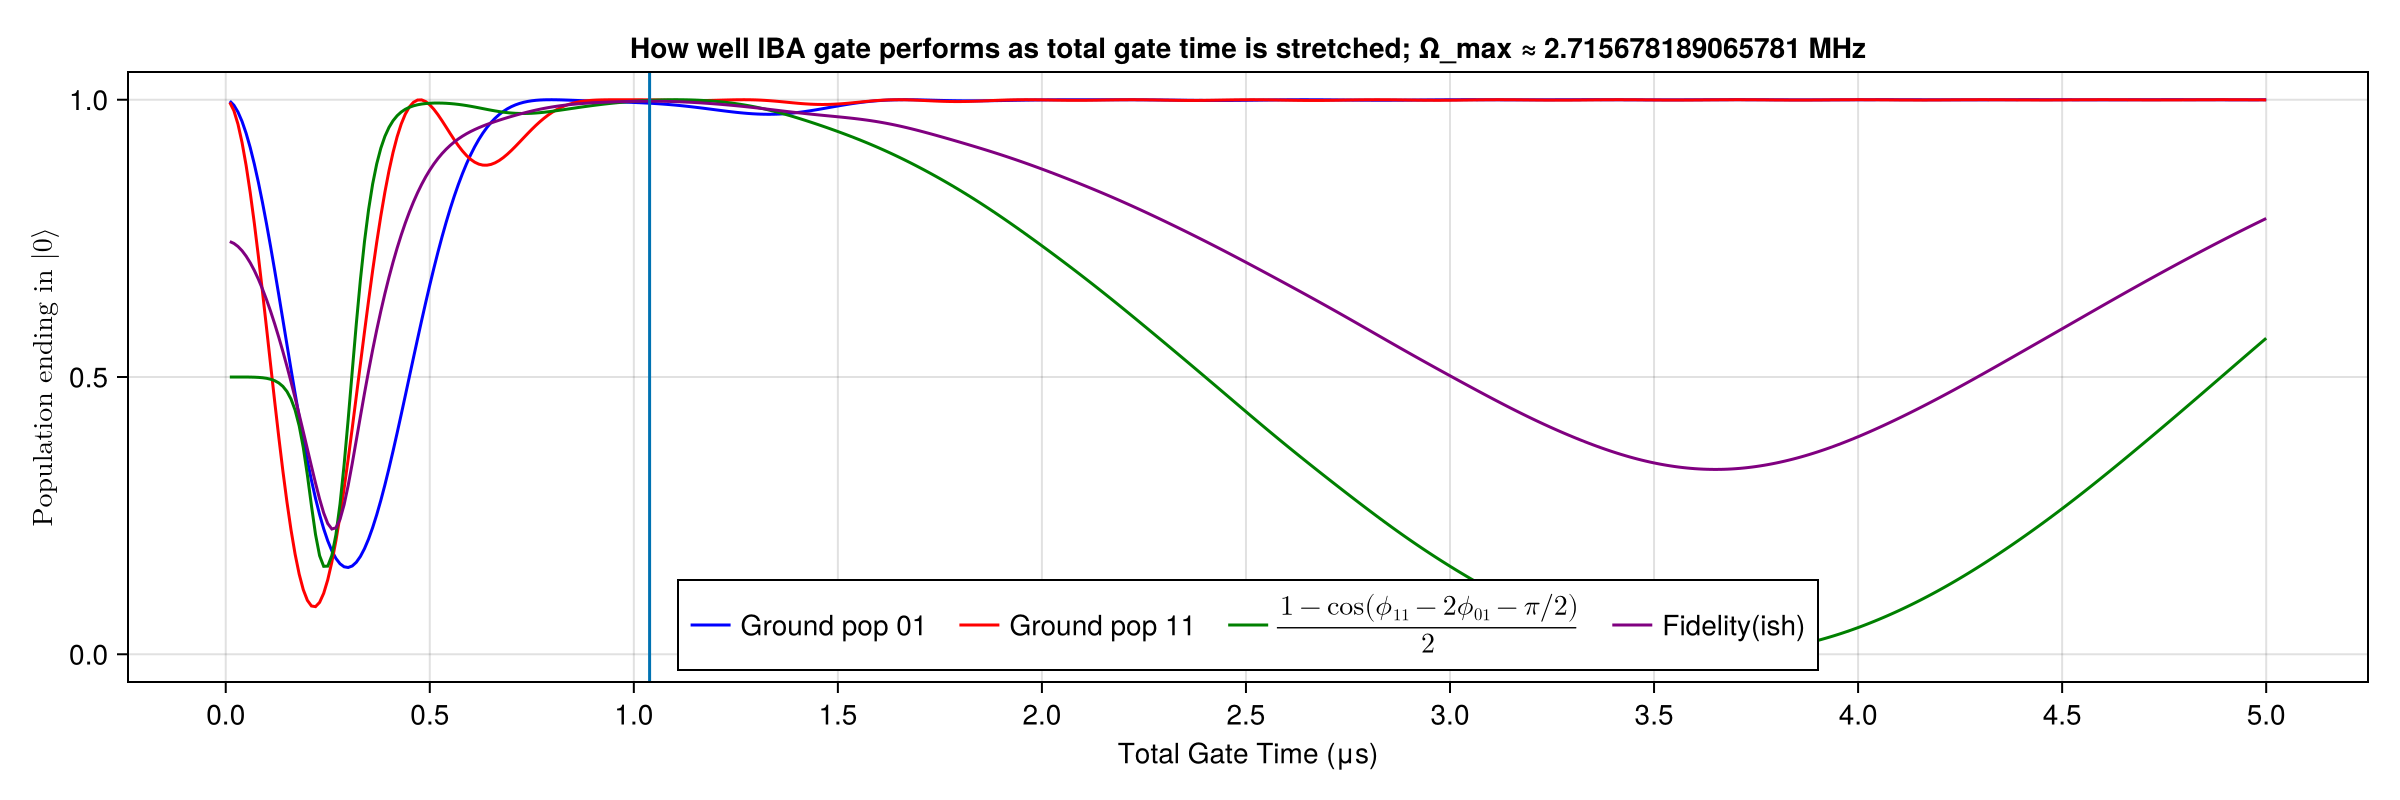

CairoMakie.Screen{IMAGE}


In [16]:
using Interpolations
using QuantumOptics
using CairoMakie


function iba_gate(T::Real, Ω_max=1)
    fudge_factor = 1.65 # this was not part of the original gate but is needed for the simulation to match the experimental data
    Ω_points = fudge_factor*2π .* [0.0, 0.412, 0.825, 1.237, 1.485, 1.485, 1.237, 0.825, 0.412, 0.0] #MHz I think
    Δ_points = 2π .* [4.08, 3.06, 2.04, 1.02, 0.408, 0.408, 1.02, 2.04, 3.06, 4.08] #MHz I think

    ts = range(0, T, length(Ω_points))
    Δ(t) = cubic_spline_interpolation(ts, Δ_points)(t) # this could also be `Ω = cubic_spline_interpolation(ts, Ω_points)` ¯\_(ツ)_/¯
    helper(t) = cubic_spline_interpolation(ts, Ω_points)(t)
    Ω(t) = Ω_max * helper(t)/helper(T/2)*2π
    ϕ(t) = 0

    (tout, psi_t, H) = twoLevelSysFromParameters(down, Δ, Ω, ϕ, T)
    return (tout, psi_t, H), (Δ, Ω, ϕ) # returns a lot of stuff but they are all useful
end


iterations = 500
tmin = 0.01
tmax = 5
Ts = range(tmin, tmax, iterations)

# 01 bloch sphere
gate_01_results = iba_gate.(Ts, Ω_max_opt)
psi_t = getindex.(getindex.(gate_01_results,1), 2)
psi_end = getindex.(psi_t, length(psi_t[1]))
down_end_amplitude = getindex.(psi_end, 2)
ending_population_01 = abs2.(down_end_amplitude)
zero_inner_01 = abs.(down_end_amplitude)
ϕ_01 = angle.(down_end_amplitude)

# 11 bloch sphere
gate_11_results = iba_gate.(Ts, sqrt(2)*Ω_max_opt)
psi_t = getindex.(getindex.(gate_11_results,1), 2)
psi_end = getindex.(psi_t, length(psi_t[1]))
down_end_amplitude = getindex.(psi_end, 2)
ending_population_11 = abs2.(down_end_amplitude)
zero_inner_11 = abs.(down_end_amplitude)
ϕ_11 = angle.(down_end_amplitude)

phase_accum = ϕ_11 .- 2 .* ϕ_01
cos_phase_accum = (1 .+ cos.(phase_accum .- π/2)) ./ 2
fidelity = abs.((2 .* zero_inner_01 .+ cis.(phase_accum .- π/2 ) .* zero_inner_11) ./ 3)


# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well IBA gate performs as total gate time is stretched; Ω_max ≈ $Ω_max_opt MHz",
    xlabel = "Total Gate Time (μs)",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (0:0.5:tmax)
)

lines!(ax1, Ts, ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, Ts, ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, Ts, cos_phase_accum, color = :green, label = L"\frac{1-\cos(\phi_{11} - 2\phi_{01} - \pi/2)}{2}")
lines!(ax1, Ts, fidelity, color = :purple, label = "Fidelity(ish)")
vlines!(ax1, [T_opt])

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)

In [17]:
maxF, index = findmax(fidelity)
maxF_time = Ts[index]

print("F(t=$maxF_time)=$maxF")

F(t=1.04)=0.9973595196864817

So we see that the known pulse shape is close to what Nedler Mead finds as optimal nearby out guess.

What if we add another small degree of freedom, allowing for small changes in the shape of the pulses.

Guess Ω_max= 9.533838646115415
Initial infidelity: 1
 * Status: success

 * Candidate solution
    Final objective value:     1.000000e+00

 * Found with
    Algorithm:     Nelder-Mead

 * Convergence measures
    √(Σ(yᵢ-ȳ)²)/n ≤ 1.0e-08

 * Work counters
    Seconds run:   0  (vs limit Inf)
    Iterations:    0
    f(x) calls:    5

[2.0, 2.7, 0.0]


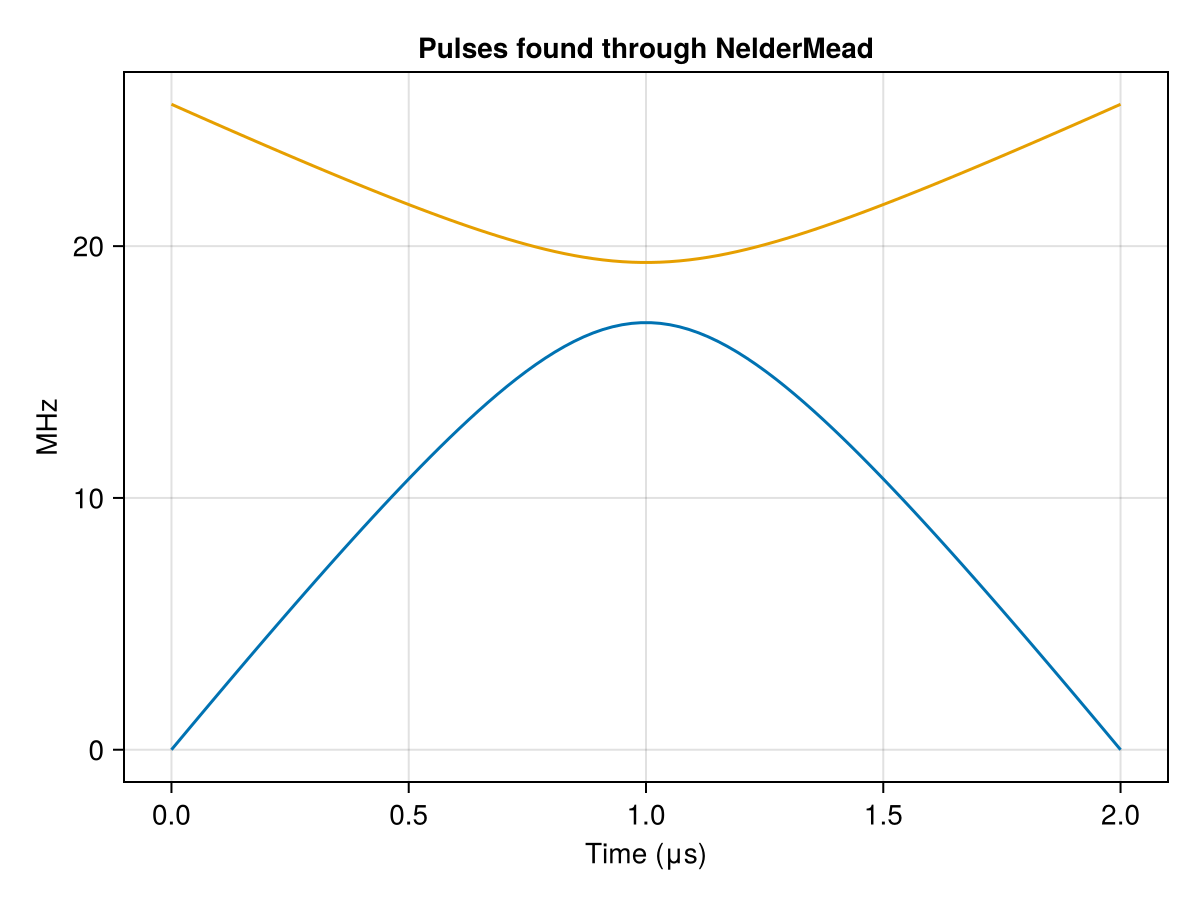

CairoMakie.Screen{IMAGE}


In [45]:
using Interpolations
using QuantumOptics
using CairoMakie

G(t, b) = 1 - 2*(sqrt(t^2*(1+4(2^b/4)) + (2^b/4)^2) - (2^b/4))

Ω_points = 2π .* [0.0, 0.412, 0.825, 1.237, 1.485, 1.485, 1.237, 0.825, 0.412, 0.0] #MHz I think
Δ_points = 2π .* [4.08, 3.06, 2.04, 1.02, 0.408, 0.408, 1.02, 2.04, 3.06, 4.08] #MHz I think

function alt_iba_pulse(T::Real, Ω_max=1, b=0)
    Δ(t) = Δ_points[1] - (Δ_points[1]-Δ_points[5])*2π*G(t/T - 1/2, b)
    Ω(t) = Ω_max*2π*G(t/T - 1/2, b)
    ϕ(t) = 0

    (tout, psi_t, H) = twoLevelSysFromParameters(down, Δ, Ω, ϕ, T)
    return (tout, psi_t, H), (Δ, Ω, ϕ) # returns a lot of stuff but they are all useful
end

function alt_iba_infidelity(T::Real, Ω_max=1, b::Real=0)
    (_, psi_01_t, H), _ = alt_iba_pulse(T, Ω_max, b)
    (_, psi_11_t, H), _ = alt_iba_pulse(T, sqrt(2)*Ω_max, b)

    # 01 bloch sphere
    psi_01_end = psi_01_t[end]
    down_end_amplitude = getindex(psi_01_end, 2)
    ending_population_01 = abs2(down_end_amplitude)
    zero_inner_01 = abs(down_end_amplitude)
    ϕ_01 = angle(down_end_amplitude)

    # 11 bloch sphere
    psi_11_end = psi_11_t[end]
    down_end_amplitude = getindex(psi_11_end, 2)
    ending_population_11 = abs2(down_end_amplitude)
    zero_inner_11 = abs(down_end_amplitude)
    ϕ_11 = angle(down_end_amplitude)

    phase_accum = ϕ_11 - 2 * ϕ_01
    cos_phase_accum = (1 + cos(phase_accum - π/2)) / 2
    fidelity = abs((2 * zero_inner_01 + cis(phase_accum - π/2 ) * zero_inner_11) / 3)
    return 1-fidelity
end

using Optim
struct MySimplexer <: Optim.Simplexer end
Optim.simplexer(S::MySimplexer, initial_x) = [rand(length(initial_x)) for i = 1:length(initial_x)+1]

f(X::Vector{Float64}) = (X[1] > 1.5) || (X[2] > 3) ? 1 : alt_iba_infidelity(X[1], X[2], X[3])

println("Guess Ω_max= ", Ω_helper(1/2))

guess = [2.0, 2.7, 0] # <-- GUESS HERE
println("Initial infidelity: ", f(guess))

res = optimize(f, guess, NelderMead(), Optim.Options(iterations=1000))
println(res)
T_opt, Ω_max_opt, b_opt = Optim.minimizer(res)
println(Optim.minimizer(res))


fig = Figure()
Ts = range(0, T_opt, 100)
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "Pulses found through NelderMead",
    xlabel = "Time (μs)",
    ylabel = "MHz",
    xticks = (0:0.5:T_opt)
)

Δ(t) = Δ_points[1] - 2π*G(t/T_opt - 1/2, b_opt)
Ω_01(t) = Ω_max_opt*2π*G(t/T_opt - 1/2, b_opt)
# lines!(ax1, Ts, Δ)
# lines!(ax1, Ts, Ω_01)
lines!(ax1, Ts, Ω_01)
lines!(ax1, Ts, Δ)
display(fig)


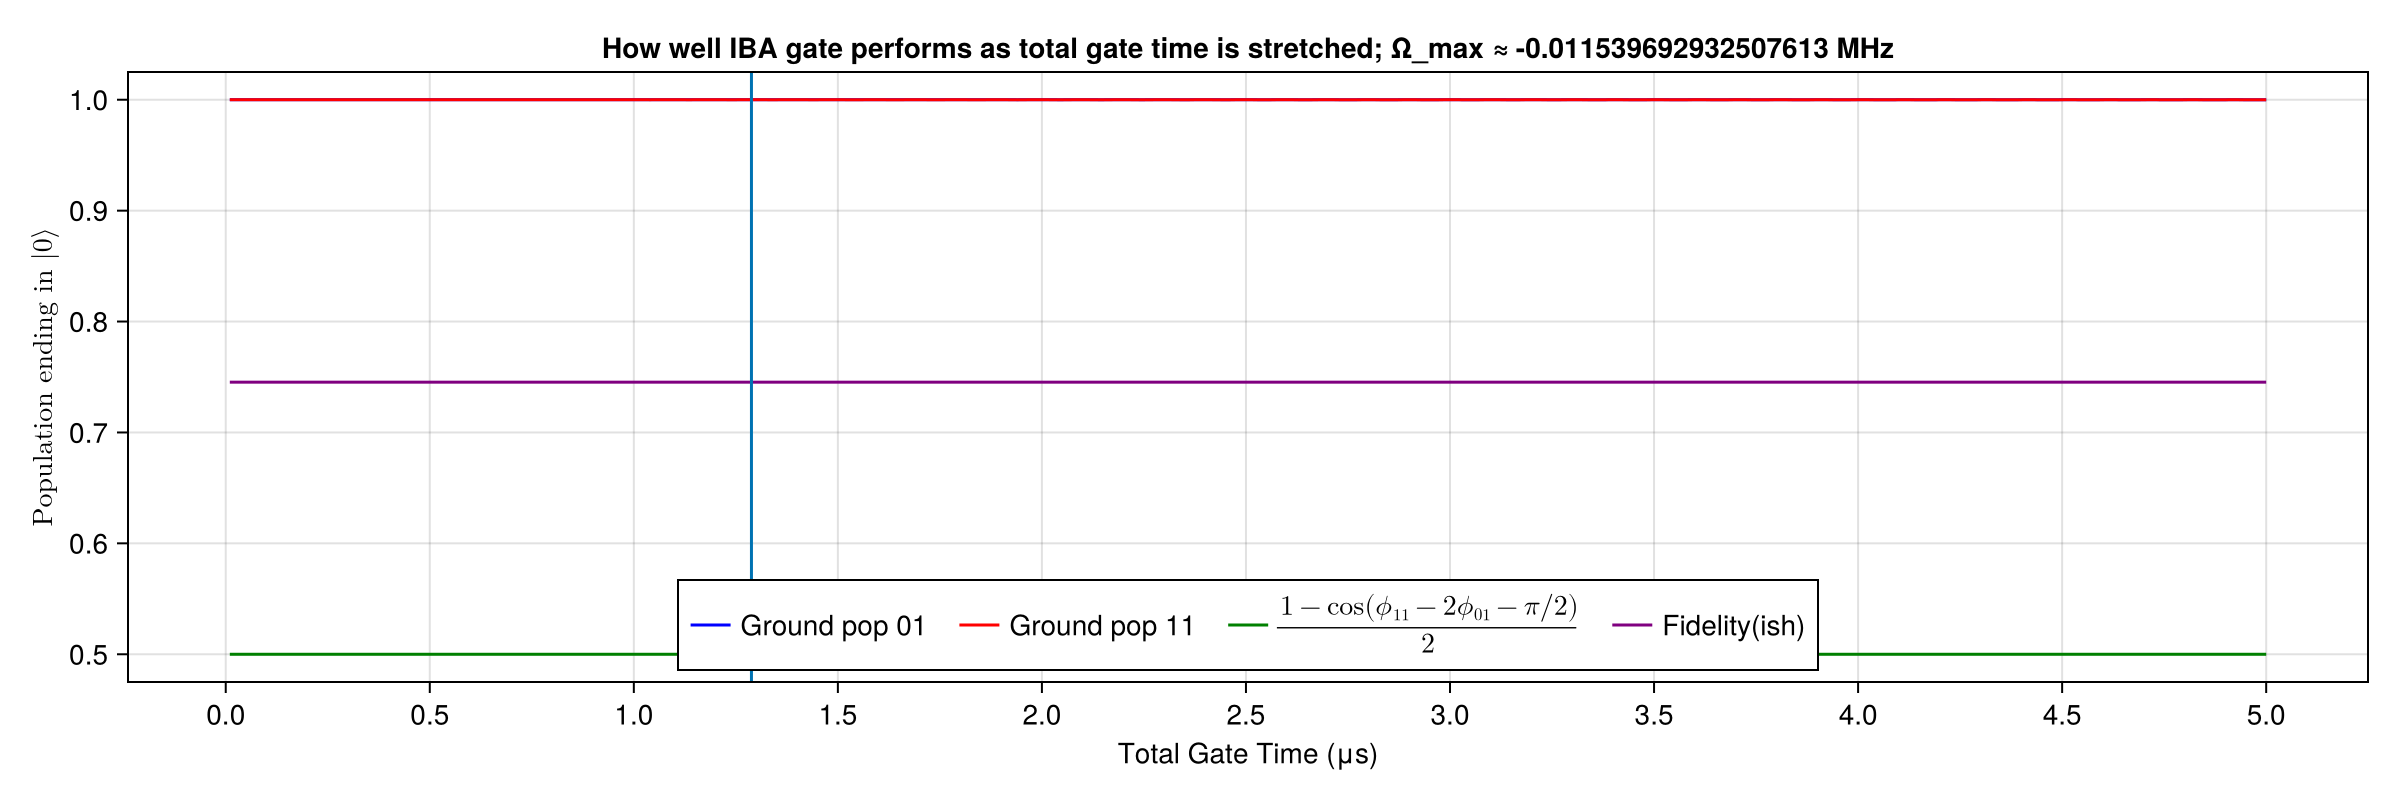

CairoMakie.Screen{IMAGE}


In [44]:
using Interpolations
using QuantumOptics
using CairoMakie

iterations = 500
tmin = 0.01
tmax = 5
Ts = range(tmin, tmax, iterations)

# 01 bloch sphere
gate_01_results = alt_iba_pulse.(Ts, Ω_max_opt,b_opt)
psi_t = getindex.(getindex.(gate_01_results,1), 2)
psi_end = getindex.(psi_t, length(psi_t[1]))
down_end_amplitude = getindex.(psi_end, 2)
ending_population_01 = abs2.(down_end_amplitude)
zero_inner_01 = abs.(down_end_amplitude)
ϕ_01 = angle.(down_end_amplitude)

# 11 bloch sphere
gate_11_results = alt_iba_pulse.(Ts, sqrt(2)*Ω_max_opt, b_opt)
psi_t = getindex.(getindex.(gate_11_results,1), 2)
psi_end = getindex.(psi_t, length(psi_t[1]))
down_end_amplitude = getindex.(psi_end, 2)
ending_population_11 = abs2.(down_end_amplitude)
zero_inner_11 = abs.(down_end_amplitude)
ϕ_11 = angle.(down_end_amplitude)

phase_accum = ϕ_11 .- 2 .* ϕ_01
cos_phase_accum = (1 .+ cos.(phase_accum .- π/2)) ./ 2
fidelity = abs.((2 .* zero_inner_01 .+ cis.(phase_accum .- π/2 ) .* zero_inner_11) ./ 3)


# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well IBA gate performs as total gate time is stretched; Ω_max ≈ $Ω_max_opt MHz",
    xlabel = "Total Gate Time (μs)",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (0:0.5:tmax)
)

lines!(ax1, Ts, ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, Ts, ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, Ts, cos_phase_accum, color = :green, label = L"\frac{1-\cos(\phi_{11} - 2\phi_{01} - \pi/2)}{2}")
lines!(ax1, Ts, fidelity, color = :purple, label = "Fidelity(ish)")
vlines!(ax1, [T_opt])

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)

Grape Results
----------------


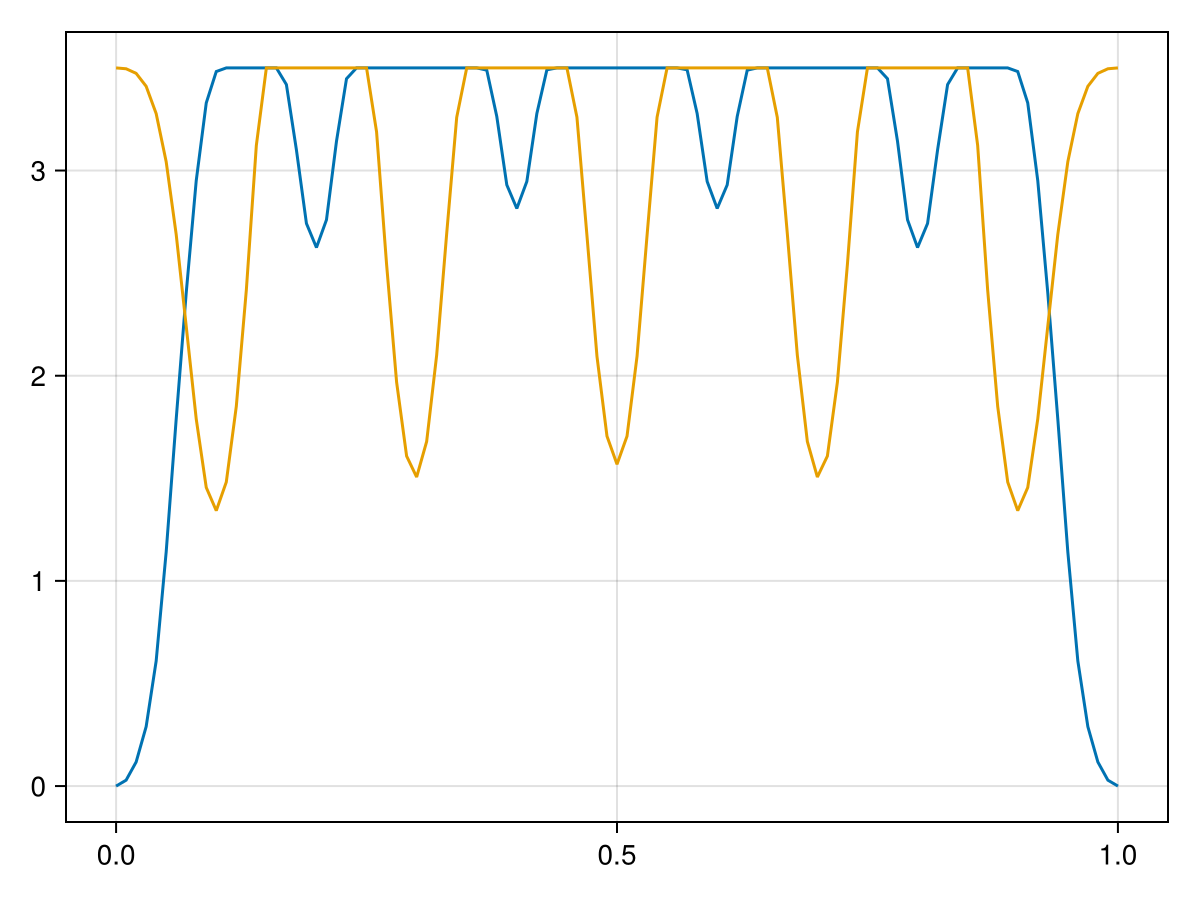

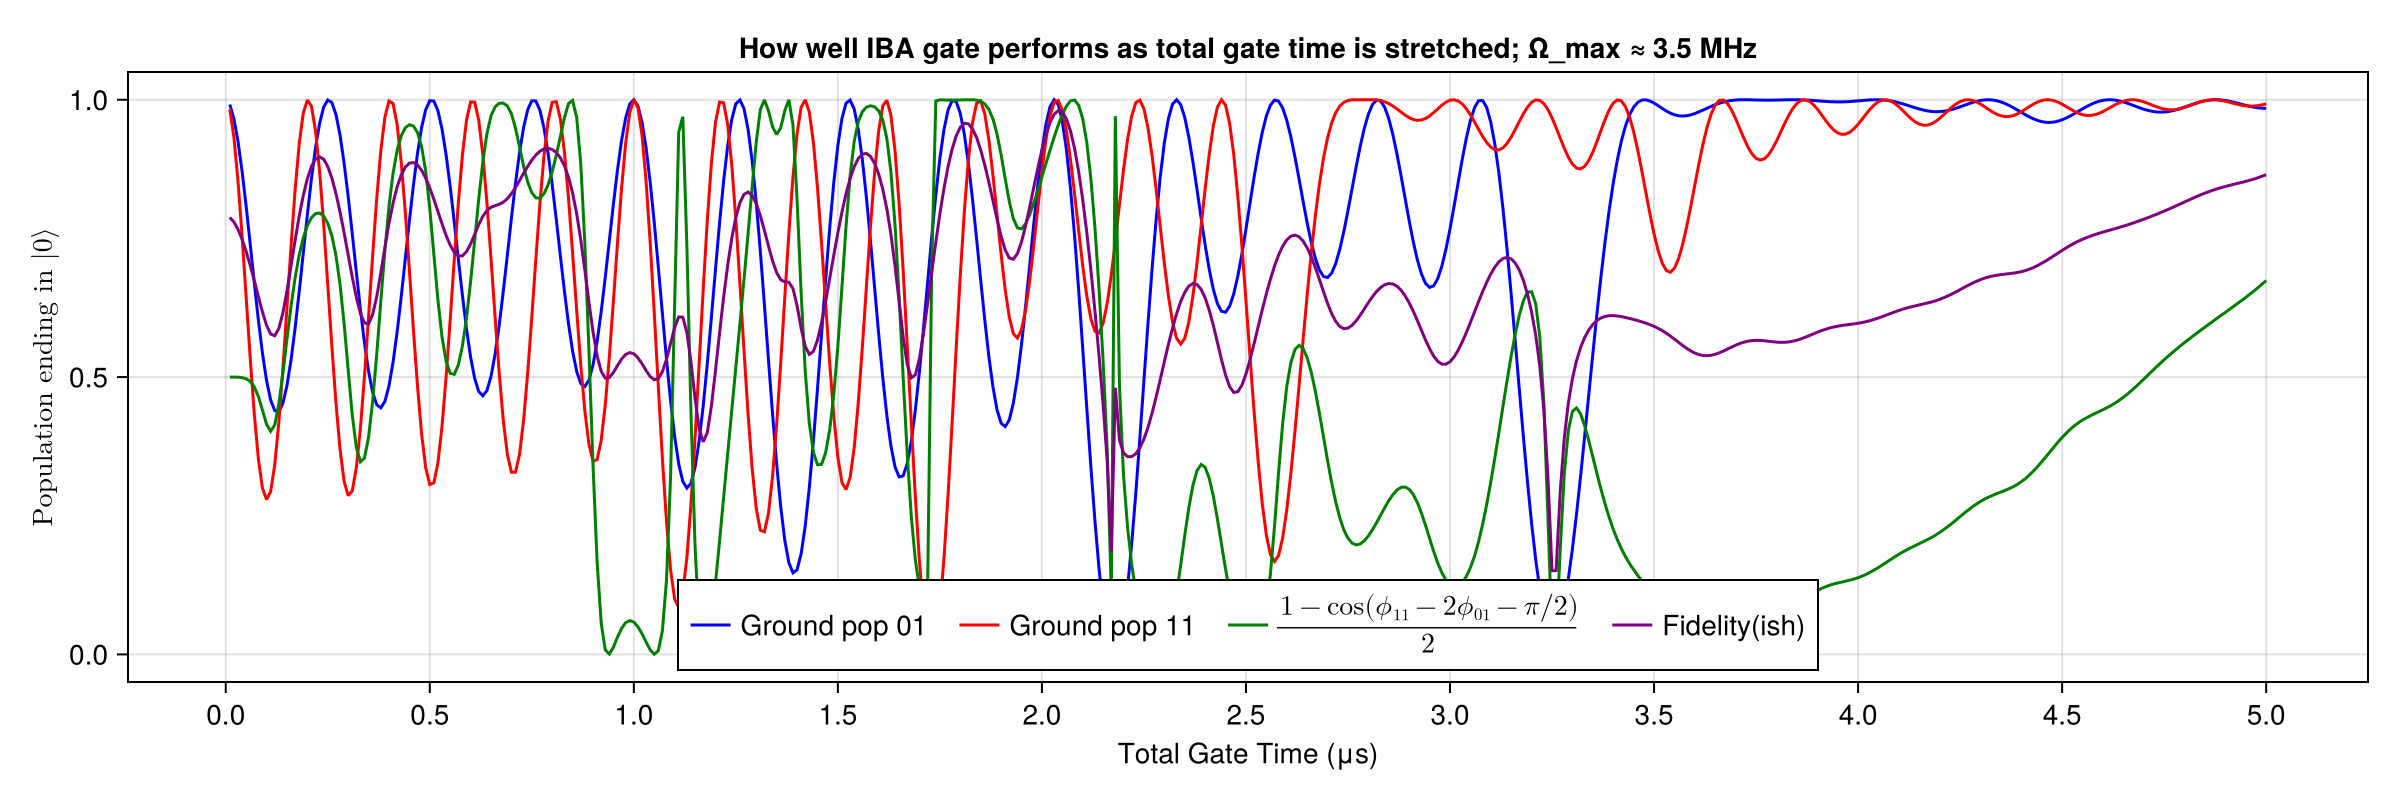

CairoMakie.Screen{IMAGE}


In [35]:
using Interpolations
Ω_points = [-2.3543112361558264e-16, 0.18141122398208054, 0.7370871792408377, 1.819998076220323, 3.830715710907785, 7.171040542488101, 11.238633006498953, 15.10270519277254, 18.539412098688704, 20.91858279491523, 21.88040875545637, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.48115748540095, 19.480904406000853, 17.228057784366733, 16.49044234890561, 17.33985332782523, 19.7461096466807, 21.659536379122805, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.92226297064861, 20.504666293375156, 18.408888675547836, 17.686409585812566, 18.513527219902905, 20.59458331165091, 21.932128899867834, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.932128899867777, 20.594583311650524, 18.513527219902393, 17.686409585812356, 18.40888867554802, 20.50466629337543, 21.922262970648667, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.659536379122983, 19.74610964668103, 17.339853327825523, 16.490442348905766, 17.22805778436674, 19.480904406000846, 21.48115748540095, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.88040875545637, 20.91858279491523, 18.5394120986887, 15.102705192772527, 11.238633006498954, 7.171040542488187, 3.8307157109078536, 1.8199980762203414, 0.7370871792408419, 0.18141122398208168, -2.3543112361558264e-16]
Δ_points = [21.991148575128552, 21.96471791619144, 21.824668963535892, 21.428377546759975, 20.591847470128855, 19.117477275205058, 16.89054264088027, 14.078190858964325, 11.239776818068279, 9.142883826701588, 8.434132639169025, 9.309351691359149, 11.627814750678416, 15.186743485231865, 19.618959317952662, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 20.03482671887091, 15.976935988926819, 12.369355085674915, 10.104883275319358, 9.463348955217803, 10.550979946267905, 13.197711944654735, 16.91940909176784, 20.478114172992107, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 20.484141523782736, 16.85995994072831, 13.159007656194689, 10.714697699138123, 9.854165494906677, 10.714697699138537, 13.159007656195495, 16.85995994072937, 20.484141523783297, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 20.478114172991894, 16.91940909176737, 13.197711944654312, 10.550979946267617, 9.46334895521769, 10.104883275319462, 12.369355085675235, 15.97693598892386, 20.03482671886773, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 21.991148575128552, 19.61895931795308, 15.186743485232654, 11.627814750679015, 9.30935169135943, 8.434132639168997, 9.142883826701402, 11.239776818068064, 14.078190858964085, 16.890542640880064, 19.117477275204926, 20.591847470128762, 21.428377546759943, 21.824668963535892, 21.96471791619144, 21.991148575128552]
ts = range(0, 1, length(Ω_points))

Δ(t) = linear_interpolation(ts, Δ_points)(t)/(2π)
Ω(t) = linear_interpolation(ts, Ω_points)(t)/(2π)

# pulse shape
fig_pulses = Figure()
ax = Axis(fig_pulses[1,1])
lines!(ax, ts, Ω)
lines!(ax, ts, Δ)
display(fig_pulses)



function iba_gate(T::Real, Ω_mult=1)
    ts = range(0, T, length(Ω_points))
    Δ(t) = linear_interpolation(ts, Δ_points)(t) # this could also be `Ω = cubic_spline_interpolation(ts, Ω_points)` ¯\_(ツ)_/¯
    Ω(t) = Ω_mult*linear_interpolation(ts, Ω_points)(t)
    ϕ(t) = 0

    (tout, psi_t, H) = twoLevelSysFromParameters(down, Δ, Ω, ϕ, T)
    return (tout, psi_t, H), (Δ, Ω, ϕ) # returns a lot of stuff but they are all useful
end


iterations = 500
tmin = 0.01
tmax = 5
Ts = range(tmin, tmax, iterations)

# 01 bloch sphere
gate_01_results = iba_gate.(Ts, 1)
psi_t = getindex.(getindex.(gate_01_results,1), 2)
psi_end = getindex.(psi_t, length(psi_t[1]))
down_end_amplitude = getindex.(psi_end, 2)
ending_population_01 = abs2.(down_end_amplitude)
zero_inner_01 = abs.(down_end_amplitude)
ϕ_01 = angle.(down_end_amplitude)

# 11 bloch sphere
gate_11_results = iba_gate.(Ts, sqrt(2)*1)
psi_t = getindex.(getindex.(gate_11_results,1), 2)
psi_end = getindex.(psi_t, length(psi_t[1]))
down_end_amplitude = getindex.(psi_end, 2)
ending_population_11 = abs2.(down_end_amplitude)
zero_inner_11 = abs.(down_end_amplitude)
ϕ_11 = angle.(down_end_amplitude)

phase_accum = ϕ_11 .- 2 .* ϕ_01
cos_phase_accum = (1 .+ cos.(phase_accum .- π/2)) ./ 2
fidelity = abs.((1 .+ 2 .* zero_inner_01 .+ cis.(phase_accum .- π/2 ) .* zero_inner_11) ./ 4)


# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well IBA gate performs as total gate time is stretched; Ω_max ≈ $(maximum(Ω_points)/(2π)) MHz",
    xlabel = "Total Gate Time (μs)",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (0:0.5:tmax)
)

lines!(ax1, Ts, ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, Ts, ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, Ts, cos_phase_accum, color = :green, label = L"\frac{1-\cos(\phi_{11} - 2\phi_{01} - \pi/2)}{2}")
lines!(ax1, Ts, fidelity, color = :purple, label = "Fidelity(ish)")

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)

In [36]:
maxF, index = findmax(fidelity)
maxF_time = Ts[index]

print("F(t=$maxF_time)=$maxF")

F(t=2.04)=0.9803860313996456

In [37]:
index = findfirst(x->x>0.99, fidelity)
maxF_time = Ts[index]
print("F(t=$maxF_time)=$(fidelity[index])")

ArgumentError: ArgumentError: invalid index: nothing of type Nothing